# NHTSA Early Warning System - Complete NLP Pipeline
### *"Complaints Precede Recalls: An NLP-Driven Early Warning System"*

**Project AEGIS | CARIAD India**

| Stage | Section | Method |
|---|---|---|
| 1 | Data Ingestion | NHTSA REST API + Drive caching |
| 2 | Text Preprocessing | NLTK, POS-aware lemmatization |
| 3 | Rule-Based Scoring (0-25) | Keyword tiers + structured flags |
| 4 | ML Scoring (0-75) | TF-IDF + Logistic Regression + flag boosts |
| 5 | Semantic Clustering | SBERT + UMAP + HDBSCAN |
| 6 | Defect Classification | Zero-shot (BART-large-MNLI) |
| 7 | Vehicle Aggregation | Temporal features + recall risk score |
| 8 | Validation | ROC-AUC, PR-AUC, lift, case study |

> **Scoring Architecture:**  
> `composite_score (0-100) = keyword_score (0-25) + ml_ensemble_score (0-75)`
> - keyword_score: capped at 25, deterministic, rule-based baseline
> - ml_ensemble_score: split as Score-A (defect severity 0-25) + Score-B (incident severity 0-25) + Score-C (confidence 0-25)


---
## Section 0 - Environment Setup
> Run every session before anything else.

In [1]:
# 0.1 Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT = '/content/drive/MyDrive/nhtsa_project'

import os
for folder in [
    f'{DRIVE_ROOT}/data/raw',
    f'{DRIVE_ROOT}/data/processed',
    f'{DRIVE_ROOT}/data/outputs',
]:
    os.makedirs(folder, exist_ok=True)

print(f'Drive mounted. Project root: {DRIVE_ROOT}')
print('  data/raw/       <- API pulls (permanent cache)')
print('  data/processed/ <- cleaned + scored files')
print('  data/outputs/   <- charts, final tables, models')


Mounted at /content/drive
Drive mounted. Project root: /content/drive/MyDrive/nhtsa_project
  data/raw/       <- API pulls (permanent cache)
  data/processed/ <- cleaned + scored files
  data/outputs/   <- charts, final tables, models


In [2]:
# 0.2 Install dependencies
!pip install -q requests pandas numpy matplotlib seaborn tqdm
!pip install -q nltk scikit-learn
!pip install -q sentence-transformers transformers umap-learn hdbscan


In [3]:
# 0.3 Standard imports
import requests, json, os, time, re, string, pickle, math, warnings
from datetime import datetime
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from tqdm import tqdm

import nltk
for pkg in ['stopwords','punkt','wordnet','punkt_tab','averaged_perceptron_tagger_eng']:
    nltk.download(pkg, quiet=True)

from nltk.corpus   import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk.stem     import WordNetLemmatizer
from nltk          import pos_tag

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model            import LogisticRegression
from sklearn.svm                     import LinearSVC
from sklearn.naive_bayes             import ComplementNB
from sklearn.calibration             import CalibratedClassifierCV
from sklearn.pipeline                import Pipeline
from sklearn.model_selection         import cross_val_score, StratifiedKFold, train_test_split
from sklearn.metrics                 import classification_report, roc_auc_score, average_precision_score
from sklearn.metrics.pairwise        import cosine_similarity
from scipy                           import stats

pd.set_option('display.max_colwidth', 120)
plt.style.use('seaborn-v0_8-whitegrid')
warnings.filterwarnings('ignore')
print(f'Environment ready  |  pandas {pd.__version__}  |  numpy {np.__version__}')


Environment ready  |  pandas 2.2.3  |  numpy 2.1.3


In [4]:
# 0.4 Drive path helper + cache policy
FORCE_REFETCH = False   # Set True to re-pull from API regardless of cache

def drive_path(filename: str) -> str:
    '''Convert relative path to full Drive path. Safe against double-prefixing.'''
    return filename if filename.startswith('/') else f'{DRIVE_ROOT}/{filename}'

def cache_or_fetch(filepath: str) -> bool:
    '''Returns True if API fetch needed, False if valid cache exists.'''
    if FORCE_REFETCH:
        print(f'  FORCE_REFETCH=True -> fetching fresh')
        return True
    if os.path.exists(filepath) and os.path.getsize(filepath) > 100:
        print(f'  Cache hit -> {filepath}')
        return False
    print(f'  Not cached -> fetching from API')
    return True

print('Helpers ready  |  FORCE_REFETCH =', FORCE_REFETCH)


Helpers ready  |  FORCE_REFETCH = False


---
## Section 1 - Data Ingestion
> Pulls complaints and recalls from the NHTSA API. All results cached to Drive.
> Run order: 1.1 -> 1.2 -> 1.3 -> 1.4 -> 1.5 -> 1.6 -> 1.7 -> 1.8


In [5]:
# 1.1 Configuration
YEARS_TO_TARGET   = [2016, 2017, 2018, 2019, 2020]
MIN_COMPLAINTS    = 10      # Min complaints in probe year to include a model
MAX_MODELS_PER_MAKE = 2    # Cap per make -- prevents Toyota/Ford dominating
DELAY             = 0.4    # Seconds between API calls

print('Ingestion config:')
print(f'  Years            : {YEARS_TO_TARGET}')
print(f'  Min complaints   : {MIN_COMPLAINTS}')
print(f'  Max models/make  : {MAX_MODELS_PER_MAKE}')
print(f'  API delay        : {DELAY}s')


Ingestion config:
  Years            : [2016, 2017, 2018, 2019, 2020]
  Min complaints   : 10
  Max models/make  : 2
  API delay        : 0.4s


In [6]:
# 1.2 Fetch all makes that have complaint data per year
def fetch_makes_for_year(year: int) -> list[str]:
    url    = 'https://api.nhtsa.gov/products/vehicle/makes'
    params = {'modelYear': year, 'issueType': 'c'}
    try:
        r = requests.get(url, params=params, timeout=60)
        r.raise_for_status()
        return [m.get('make','') for m in r.json().get('results',[]) if m.get('make')]
    except Exception as e:
        print(f'  Makes fetch failed for {year}: {e}')
        return []

MAKES_CACHE = drive_path('data/raw/makes_by_year.json')

if not cache_or_fetch(MAKES_CACHE):
    with open(MAKES_CACHE) as f:
        makes_by_year = json.load(f)
    makes_by_year = {int(k): v for k, v in makes_by_year.items()}
    print(f'  Loaded {sum(len(v) for v in makes_by_year.values())} makes from cache')
else:
    makes_by_year = {}
    for year in YEARS_TO_TARGET:
        makes = fetch_makes_for_year(year)
        makes_by_year[year] = makes
        print(f'  {year}: {len(makes)} makes found')
        time.sleep(DELAY)
    with open(MAKES_CACHE, 'w') as f:
        json.dump(makes_by_year, f)
    print(f'  Saved -> {MAKES_CACHE}')

makes_all_years = sorted(
    make for make in set(m for makes in makes_by_year.values() for m in makes)
    if all(make in makes_by_year[y] for y in YEARS_TO_TARGET)
)
print(f'Makes present in ALL {len(YEARS_TO_TARGET)} target years: {len(makes_all_years)}')


  Cache hit -> /content/drive/MyDrive/nhtsa_project/data/raw/makes_by_year.json
  Loaded 722 makes from cache
Makes present in ALL 5 target years: 71


In [7]:
# 1.3 Fetch models per make per year
def fetch_models_for_make_year(make: str, year: int) -> list[str]:
    url    = 'https://api.nhtsa.gov/products/vehicle/models'
    params = {'modelYear': year, 'issueType': 'c', 'make': make}
    try:
        r = requests.get(url, params=params, timeout=60)
        r.raise_for_status()
        return [m.get('model','') for m in r.json().get('results',[]) if m.get('model')]
    except Exception as e:
        print(f'  Models fetch failed for {make} {year}: {e}')
        return []

MODELS_CACHE = drive_path('data/raw/models_registry.json')

if not cache_or_fetch(MODELS_CACHE):
    with open(MODELS_CACHE) as f:
        models_registry = json.load(f)
    models_registry = {
        make: {int(y): models for y, models in year_dict.items()}
        for make, year_dict in models_registry.items()
    }
    print(f'  Loaded models for {len(models_registry)} makes from cache')
else:
    models_registry = {}
    for make in tqdm(makes_all_years, desc='Fetching models'):
        models_registry[make] = {}
        for year in YEARS_TO_TARGET:
            models_registry[make][year] = fetch_models_for_make_year(make, year)
            time.sleep(DELAY)
    with open(MODELS_CACHE, 'w') as f:
        json.dump(models_registry, f)
    print(f'  Saved -> {MODELS_CACHE}')


  Cache hit -> /content/drive/MyDrive/nhtsa_project/data/raw/models_registry.json
  Loaded models for 71 makes from cache


In [8]:
# 1.4 Build consistent make-model catalogue
catalogue_rows = []
for make, year_models in models_registry.items():
    all_models = set(m for ym in year_models.values() for m in ym)
    for model in all_models:
        years_present = [y for y in YEARS_TO_TARGET if model in year_models.get(y, [])]
        catalogue_rows.append({
            'make':          make,
            'model':         model,
            'years_present': len(years_present),
            'years_list':    years_present,
            'fully_covered': len(years_present) == len(YEARS_TO_TARGET),
        })

df_catalogue = pd.DataFrame(catalogue_rows).sort_values(
    ['make','years_present'], ascending=[True, False]
)
print(f'Catalogue shape:         {df_catalogue.shape}')
print(f'Fully-covered pairs:     {df_catalogue["fully_covered"].sum()}')
print(f'Partially-covered pairs: {(~df_catalogue["fully_covered"]).sum()}')


Catalogue shape:         (1504, 5)
Fully-covered pairs:     251
Partially-covered pairs: 1253


In [9]:
# 1.5 Filter: volume probe + per-make cap -> final VEHICLES list
def fetch_complaint_count(make: str, model: str, year: int) -> int:
    url    = 'https://api.nhtsa.gov/complaints/complaintsByVehicle'
    params = {'make': make, 'model': model, 'modelYear': year}
    try:
        r = requests.get(url, params=params, timeout=60)
        r.raise_for_status()
        return len(r.json().get('results', []))
    except Exception:
        return 0

df_covered  = df_catalogue[df_catalogue['fully_covered']].copy()
probe_year  = YEARS_TO_TARGET[len(YEARS_TO_TARGET) // 2]
PROBE_CACHE = drive_path(f'data/raw/complaint_probe_{probe_year}.csv')

if not cache_or_fetch(PROBE_CACHE):
    probe_cached = pd.read_csv(PROBE_CACHE)[['make','model',f'complaints_{probe_year}']]
    df_covered   = df_covered.merge(probe_cached, on=['make','model'], how='left')
else:
    complaint_counts = []
    for _, row in tqdm(df_covered.iterrows(), total=len(df_covered), desc='Probing'):
        complaint_counts.append(fetch_complaint_count(row['make'], row['model'], probe_year))
        time.sleep(DELAY)
    df_covered[f'complaints_{probe_year}'] = complaint_counts
    df_covered[['make','model',f'complaints_{probe_year}']].to_csv(PROBE_CACHE, index=False)
    print(f'  Saved -> {PROBE_CACHE}')

# Pass 1: volume filter | Pass 2: per-make cap
df_filtered = df_covered[df_covered[f'complaints_{probe_year}'] >= MIN_COMPLAINTS].copy()
df_selected = (
    df_filtered
    .sort_values(['make', f'complaints_{probe_year}'], ascending=[True, False])
    .groupby('make', group_keys=False)[df_filtered.columns]
    .head(MAX_MODELS_PER_MAKE)
    .reset_index(drop=True)
)

VEHICLES = [
    {'make': row['make'], 'model': row['model'], 'years': YEARS_TO_TARGET}
    for _, row in df_selected.iterrows()
]

print('FINAL VEHICLE SELECTION')
print(df_selected[['make','model',f'complaints_{probe_year}']].to_string(index=False))
print(f'Total pairs selected: {len(VEHICLES)}')
print(f'Total API cells:      {len(VEHICLES) * len(YEARS_TO_TARGET)}')

df_catalogue.to_csv(drive_path('data/raw/vehicle_catalogue_full.csv'),    index=False)
df_selected.to_csv(drive_path('data/raw/vehicle_catalogue_selected.csv'), index=False)
print('Catalogues saved')


  Cache hit -> /content/drive/MyDrive/nhtsa_project/data/raw/complaint_probe_2018.csv
FINAL VEHICLE SELECTION
                make             model  complaints_2018
               ACURA               MDX              162
               ACURA               TLX               93
                AUDI                Q5              197
                AUDI                Q7              141
                 BMW                X3               72
                 BMW                X5               69
               BUICK            ENCORE               74
               BUICK           ENCLAVE               64
            CADILLAC      ESCALADE ESV               35
            CADILLAC          ESCALADE               21
              CAN-AM         SPYDER F3               12
              CAN-AM         SPYDER RT               10
           CHEVROLET            MALIBU              694
           CHEVROLET    SILVERADO 1500              510
            CHRYSLER          PACIFICA            

In [10]:
# 1.6 Pull full complaints (cache-aware)
def fetch_complaints(make: str, model: str, year: int) -> list:
    url    = 'https://api.nhtsa.gov/complaints/complaintsByVehicle'
    params = {'make': make, 'model': model, 'modelYear': year}
    try:
        r = requests.get(url, params=params, timeout=60)
        r.raise_for_status()
        results = r.json().get('results', [])
        for rec in results:
            rec['make_pulled']  = make
            rec['model_pulled'] = model
            rec['year_pulled']  = year
        time.sleep(DELAY)
        return results
    except Exception as e:
        print(f'  {make} {model} {year}: {e}')
        return []

COMPLAINTS_CACHE = drive_path('data/raw/complaints_raw.csv')

if not cache_or_fetch(COMPLAINTS_CACHE):
    df_complaints = pd.read_csv(COMPLAINTS_CACHE)
    print(f'  Loaded {len(df_complaints):,} complaints from cache')
else:
    all_complaints = []
    for vehicle in VEHICLES:
        for year in vehicle['years']:
            records = fetch_complaints(vehicle['make'], vehicle['model'], year)
            all_complaints.extend(records)
            print(f'  {vehicle["make"]} {vehicle["model"]} {year}: {len(records)} complaints')
    df_complaints = pd.DataFrame(all_complaints)
    df_complaints.to_csv(COMPLAINTS_CACHE, index=False)
    print(f'Saved {len(df_complaints):,} complaints')

print(f'Total complaints: {len(df_complaints):,}')
print(f'Unique vehicles:  {df_complaints.groupby(["make_pulled","model_pulled","year_pulled"]).ngroups}')


  Cache hit -> /content/drive/MyDrive/nhtsa_project/data/raw/complaints_raw.csv
  Loaded 85,998 complaints from cache
Total complaints: 85,998
Unique vehicles:  315


In [11]:
# 1.7 Pull recalls (cache-aware, with model name normalisation)
import re as _re

def _normalise_model(model: str) -> str:
    return _re.sub(r'[-\s]+', ' ', model.strip().upper())

def fetch_recalls_v2(make: str, model: str, year: int) -> list:
    url = 'https://api.nhtsa.gov/recalls/recallsByVehicle'
    for model_attempt in sorted({model, _normalise_model(model)}):
        params = {'make': make, 'model': model_attempt, 'modelYear': year}
        try:
            r = requests.get(url, params=params, timeout=60)
            r.raise_for_status()
            results = r.json().get('results', [])
            if results:
                for rec in results:
                    rec['make_pulled']  = make
                    rec['model_pulled'] = model
                    rec['year_pulled']  = year
                time.sleep(DELAY)
                return results
        except Exception as e:
            print(f'  {make} {model_attempt} {year}: {e}')
    time.sleep(DELAY)
    return []

RECALLS_CACHE = drive_path('data/raw/recalls_raw.csv')

if not cache_or_fetch(RECALLS_CACHE):
    df_recalls = pd.read_csv(RECALLS_CACHE)
    print(f'  Loaded {len(df_recalls):,} recalls from cache')
else:
    all_recalls = []
    for vehicle in VEHICLES:
        for year in vehicle['years']:
            records = fetch_recalls_v2(vehicle['make'], vehicle['model'], year)
            all_recalls.extend(records)
            print(f'  {vehicle["make"]} {vehicle["model"]} {year}: {len(records)} recalls')
    df_recalls = pd.DataFrame(all_recalls) if all_recalls else pd.DataFrame()
    df_recalls.to_csv(RECALLS_CACHE, index=False)
    print(f'  Saved -> {RECALLS_CACHE}')

print(f'Total recall records: {len(df_recalls):,}')


  Cache hit -> /content/drive/MyDrive/nhtsa_project/data/raw/recalls_raw.csv
  Loaded 1,320 recalls from cache
Total recall records: 1,320


In [12]:
# 1.7b Recall coverage audit — track which vehicles had zero API results
# This distinguishes "no recall exists" from "API returned nothing (possible mismatch)"
# recall_coverage column is used in Cell 7.3 to filter before labeling

vehicles_attempted = set()
vehicles_with_recalls = set()

for vehicle in VEHICLES:
    for year in vehicle['years']:
        vk = f"{vehicle['make'].upper()}_{vehicle['model'].upper()}_{year}"
        vehicles_attempted.add(vk)

if len(df_recalls) > 0:
    for _, row in df_recalls.iterrows():
        vk = f"{str(row['make_pulled']).upper()}_{str(row['model_pulled']).upper()}_{row['year_pulled']}"
        vehicles_with_recalls.add(vk)

vehicles_no_recall_data = vehicles_attempted - vehicles_with_recalls

print(f'Vehicles attempted (API called)   : {len(vehicles_attempted)}')
print(f'Vehicles with >=1 recall returned : {len(vehicles_with_recalls)}')
print(f'Vehicles with zero recall data    : {len(vehicles_no_recall_data)}')
print(f'  (These will be EXCLUDED from ROC-AUC evaluation, not labeled as non-recalled)')

# Save coverage set for use in Section 7
import json
with open(drive_path('data/raw/recall_coverage.json'), 'w') as f:
    json.dump({
        'vehicles_attempted':    sorted(vehicles_attempted),
        'vehicles_with_recalls': sorted(vehicles_with_recalls),
        'vehicles_no_data':      sorted(vehicles_no_recall_data),
    }, f, indent=2)
print('Coverage metadata saved -> data/raw/recall_coverage.json')

Vehicles attempted (API called)   : 315
Vehicles with >=1 recall returned : 262
Vehicles with zero recall data    : 53
  (These will be EXCLUDED from ROC-AUC evaluation, not labeled as non-recalled)
Coverage metadata saved -> data/raw/recall_coverage.json


In [13]:
# 1.8 Joint audit (complaints vs recalls)
complaints_summary = (
    df_complaints
    .groupby(['make_pulled','model_pulled','year_pulled'])
    .size().reset_index(name='complaint_count')
)
recalls_summary = (
    df_recalls.groupby(['make_pulled','model_pulled','year_pulled'])
    .size().reset_index(name='recall_count')
) if len(df_recalls) > 0 else pd.DataFrame(
    columns=['make_pulled','model_pulled','year_pulled','recall_count']
)

joint = complaints_summary.merge(
    recalls_summary, on=['make_pulled','model_pulled','year_pulled'], how='left'
)
joint['recall_count'] = joint['recall_count'].fillna(0).astype(int)
joint['has_recall']   = (joint['recall_count'] > 0).astype(int)
joint['vehicle_key']  = (
    joint['make_pulled']  + '_' +
    joint['model_pulled'] + '_' +
    joint['year_pulled'].astype(str)
)

print('JOINT COMPLAINT + RECALL SUMMARY')
print(joint.sort_values('complaint_count', ascending=False).to_string(index=False))
print(f'With recalls: {joint["has_recall"].sum()} | Without: {(1-joint["has_recall"]).sum()}')
print(f'Mean complaints WITH recall:    {joint[joint["has_recall"]==1]["complaint_count"].mean():.1f}')
print(f'Mean complaints WITHOUT recall: {joint[joint["has_recall"]==0]["complaint_count"].mean():.1f}')

joint.to_csv(drive_path('data/raw/vehicle_joint_summary.csv'), index=False)
print('Joint summary saved')


JOINT COMPLAINT + RECALL SUMMARY
         make_pulled      model_pulled  year_pulled  complaint_count  recall_count  has_recall                          vehicle_key
                 RAM              2500         2018             2534            10           1                        RAM_2500_2018
               HONDA              CR-V         2018             2112             5           1                      HONDA_CR-V_2018
                FORD F-150 REGULAR CAB         2018             1835             0           0          FORD_F-150 REGULAR CAB_2018
                FORD    F-150 SUPERCAB         2018             1835             0           0             FORD_F-150 SUPERCAB_2018
               HONDA            ACCORD         2018             1833             6           1                    HONDA_ACCORD_2018
                JEEP          WRANGLER         2018             1800            14           1                   JEEP_WRANGLER_2018
               HONDA              CR-V     

In [14]:
# 1.9 Section 1 checkpoint
expected = {
    drive_path('data/raw/complaints_raw.csv')             : df_complaints,
    drive_path('data/raw/recalls_raw.csv')                : df_recalls,
    drive_path('data/raw/vehicle_catalogue_full.csv')     : df_catalogue,
    drive_path('data/raw/vehicle_catalogue_selected.csv') : df_selected,
    drive_path('data/raw/vehicle_joint_summary.csv')      : joint,
}
print('SECTION 1 CHECKPOINT')
all_ok = True
for path, df in expected.items():
    exists = os.path.exists(path)
    rows   = len(df) if df is not None and len(df) > 0 else 0
    status = 'OK' if exists and rows > 0 else 'MISSING'
    if not (exists and rows > 0): all_ok = False
    print(f'  {status}  {os.path.basename(path):<45} {rows:>6,} rows')
print()
if all_ok:
    print('All Section 1 files confirmed. Safe to proceed to Section 2.')
else:
    print('Re-run flagged cells above before continuing.')


SECTION 1 CHECKPOINT
  OK  complaints_raw.csv                            85,998 rows
  OK  recalls_raw.csv                                1,320 rows
  OK  vehicle_catalogue_full.csv                     1,504 rows
  OK  vehicle_catalogue_selected.csv                    63 rows
  OK  vehicle_joint_summary.csv                        315 rows

All Section 1 files confirmed. Safe to proceed to Section 2.


---
## Section 2 - Text Preprocessing
> **NLP Concept:** Domain-aware cleaning pipeline.
> Raw complaint text is messy (all caps, abbreviations, punctuation noise).
> Each step reduces vocabulary fragmentation and improves downstream model signal.


In [15]:
# 2.0 Reload if starting fresh session
df_complaints = pd.read_csv(drive_path('data/raw/complaints_raw.csv'))
df_recalls    = pd.read_csv(drive_path('data/raw/recalls_raw.csv'))
TEXT_COL      = 'summary'
print(f'Loaded {len(df_complaints):,} complaints, {len(df_recalls):,} recalls')

# Quick EDA before cleaning
df_complaints['text_length'] = df_complaints[TEXT_COL].fillna('').str.len()
df_complaints['word_count']  = df_complaints[TEXT_COL].fillna('').str.split().str.len()
print('Text length stats (chars):')
print(df_complaints['text_length'].describe().round(0))


Loaded 85,998 complaints, 1,320 recalls
Text length stats (chars):
count    85998.0
mean       569.0
std        425.0
min          0.0
25%        262.0
50%        478.0
75%        744.0
max       2794.0
Name: text_length, dtype: float64


In [16]:
# 2.1 Pipeline constants
STOP_WORDS        = set(stopwords.words('english'))
KEEP_NEGATIONS    = {'not','no','never','without','none','nobody'}
DOMAIN_STOP_WORDS = STOP_WORDS - KEEP_NEGATIONS

# Automotive abbreviation expansion -- unifies synonyms before TF-IDF
AUTOMOTIVE_ABBREVIATIONS = {
    r'\babs\b':   'antilock braking system',
    r'\baeb\b':   'automatic emergency braking',
    r'\bfcw\b':   'forward collision warning',
    r'\becu\b':   'electronic control unit',
    r'\blks\b':   'lane keeping system',
    r'\bacc\b':   'adaptive cruise control',
    r'\bepas\b':  'electric power assisted steering',
    r'\btpms\b':  'tire pressure monitoring system',
    r'\bdtc\b':   'diagnostic trouble code',
}

lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag: str) -> str:
    if tag.startswith('V'): return wordnet.VERB
    if tag.startswith('J'): return wordnet.ADJ
    if tag.startswith('R'): return wordnet.ADV
    return wordnet.NOUN

def lemmatize_with_pos(tokens: list) -> list:
    tagged = pos_tag(tokens)
    return [lemmatizer.lemmatize(w, get_wordnet_pos(t)) for w, t in tagged]


In [17]:
# 2.2 Full preprocessing function (9 steps)
def preprocess_complaint(text: str) -> dict:
    '''9-step cleaning pipeline. Returns cleaned text + intermediate steps for inspection.'''
    if not text or not isinstance(text, str):
        return {'cleaned': '', 'tokens': [], 'steps': {}}

    steps = {}
    steps['0_original'] = text[:80]

    s = text.lower()
    steps['1_lowercase'] = s[:80]

    for pattern, expansion in AUTOMOTIVE_ABBREVIATIONS.items():
        s = re.sub(pattern, expansion, s, flags=re.IGNORECASE)
    steps['2_abbr_expanded'] = s[:80]

    s = re.sub(r'https?://\S+|www\.\S+|\S+@\S+', ' ', s)
    steps['3_urls_removed'] = s[:80]

    s = re.sub(r'[^\w\s]', ' ', s)
    steps['4_punct_removed'] = s[:80]

    s = re.sub(r'(.)\1{2,}', r'\1', s)
    steps['5_repeated_chars'] = s[:80]

    s = re.sub(r'\s+', ' ', s).strip()
    steps['6_whitespace'] = s[:80]

    tokens = word_tokenize(s)
    tokens = [t for t in tokens if t not in DOMAIN_STOP_WORDS and len(t) > 1]
    lemmatized = lemmatize_with_pos(tokens)
    steps['7_lemmatized'] = lemmatized[:10]

    return {'cleaned': ' '.join(lemmatized), 'tokens': lemmatized, 'steps': steps}

# Demo on one complaint
sample_text = df_complaints[TEXT_COL].dropna().iloc[12]
print('PREPROCESSING WALK-THROUGH')
result = preprocess_complaint(sample_text)
for step_name, value in result['steps'].items():
    print(f'  {step_name}: {value}')


PREPROCESSING WALK-THROUGH
  0_original: I started the vehicle and steering wheel was frozen and EPS, Brake, and lane dep
  1_lowercase: i started the vehicle and steering wheel was frozen and eps, brake, and lane dep
  2_abbr_expanded: i started the vehicle and steering wheel was frozen and eps, brake, and lane dep
  3_urls_removed: i started the vehicle and steering wheel was frozen and eps, brake, and lane dep
  4_punct_removed: i started the vehicle and steering wheel was frozen and eps  brake  and lane dep
  5_repeated_chars: i started the vehicle and steering wheel was frozen and eps  brake  and lane dep
  6_whitespace: i started the vehicle and steering wheel was frozen and eps brake and lane depar
  7_lemmatized: ['start', 'vehicle', 'steer', 'wheel', 'frozen', 'eps', 'brake', 'lane', 'departure', 'light']


In [18]:
# 2.3 Apply to all complaints + save (single-pass — both outputs from one call)
tqdm.pandas()

preprocessing_results = (
    df_complaints[TEXT_COL].fillna('')
    .progress_apply(preprocess_complaint)
)

df_complaints['text_clean']  = preprocessing_results.apply(lambda x: x['cleaned'])
df_complaints['text_tokens'] = preprocessing_results.apply(lambda x: x['tokens'])
df_complaints['word_count_clean'] = df_complaints['text_clean'].str.split().str.len()

# Flag texts too short for reliable ML signal (< 5 words after cleaning)
df_complaints['too_short'] = df_complaints['word_count_clean'] < 5
short_count = df_complaints['too_short'].sum()

raw_vocab   = len(Counter(w for t in df_complaints[TEXT_COL].dropna() for w in t.lower().split()))
clean_vocab = len(Counter(w for tok in df_complaints['text_tokens'] for w in tok))

print(f'Preprocessing complete  (single-pass)')
print(f'  Vocabulary before : {raw_vocab:,}')
print(f'  Vocabulary after  : {clean_vocab:,}')
print(f'  Reduction         : {(1 - clean_vocab/raw_vocab):.1%}')
print(f'  Texts too short   : {short_count:,}  ({short_count/len(df_complaints):.1%}) — flagged, not dropped')

df_complaints.to_csv(drive_path('data/processed/complaints_cleaned.csv'), index=False)
print('Saved -> data/processed/complaints_cleaned.csv')

100%|██████████| 85998/85998 [07:05<00:00, 201.94it/s]


Preprocessing complete  (single-pass)
  Vocabulary before : 135,965
  Vocabulary after  : 43,759
  Reduction         : 67.8%
  Texts too short   : 1,315  (1.5%) — flagged, not dropped
Saved -> data/processed/complaints_cleaned.csv


---
## Section 3 - Rule-Based Keyword Scoring (0-25 pts)
> **Scoring Architecture -- Tier 1 of 2 (Keyword contribution)**

> Keyword score is hard-capped at **25 pts**. This prevents any single tier of keywords from
> dominating the final score, and keeps the deterministic signal from inflating scores
> on common-word complaints.

> | Sub-signal | Points | Cap |
> |---|---|---|
> | Tier 1 danger words (fire, fatality, loss of control...) | 20 per hit | 3 hits max |
> | Tier 2 safety words (crash, injury, airbag...) | 10 per hit | 3 hits max |
> | Tier 3 weak words (failed, malfunction, defect...) | 3 per hit | 4 hits max |
> | **Keyword total** | **0-25** | hard cap |


In [19]:
# 3.0 Reload
df_complaints = pd.read_csv(drive_path('data/processed/complaints_cleaned.csv'))
df_recalls    = pd.read_csv(drive_path('data/raw/recalls_raw.csv'))
TEXT_COL      = 'text_clean'
print(f'Loaded {len(df_complaints):,} complaints')


Loaded 85,998 complaints


In [20]:
# 3.1 Structured signal extraction
# Use NHTSA structured fields first -- more reliable than NLP-derived signals.
# Column names validated against actual NHTSA API response: numberOfInjuries, numberOfDeaths, components

df_complaints['has_crash'] = (
    df_complaints['crash'].fillna(False).astype(bool).astype(int)
)
df_complaints['has_fire'] = (
    df_complaints['fire'].fillna(False).astype(bool).astype(int)
)
df_complaints['has_injury'] = (
    df_complaints['numberOfInjuries'].fillna(0).astype(float).gt(0).astype(int)
)
df_complaints['has_fatality'] = (
    df_complaints['numberOfDeaths'].fillna(0).astype(float).gt(0).astype(int)
)
df_complaints['date_incident'] = pd.to_datetime(df_complaints['dateOfIncident'],    errors='coerce')
df_complaints['date_filed']    = pd.to_datetime(df_complaints['dateComplaintFiled'], errors='coerce')
df_complaints['days_to_file']  = (df_complaints['date_filed'] - df_complaints['date_incident']).dt.days
df_complaints.loc[df_complaints['days_to_file'] < 0, 'days_to_file'] = None
df_complaints['filed_quickly'] = df_complaints['days_to_file'].fillna(999).lt(30).astype(int)

print('Structured signals:')
for col in ['has_crash','has_fire','has_injury','has_fatality','filed_quickly']:
    n = df_complaints[col].sum()
    print(f'  {col:<18} {n:>6,}  ({n/len(df_complaints):.1%})')


Structured signals:
  has_crash           3,138  (3.6%)
  has_fire            1,134  (1.3%)
  has_injury          1,895  (2.2%)
  has_fatality           36  (0.0%)
  filed_quickly      54,032  (62.8%)


In [21]:
# 3.2 Component risk extraction
import ast

def parse_components(raw) -> list:
    if not isinstance(raw, str) or not raw.strip(): return []
    stripped = raw.strip()
    if stripped.startswith('['):
        try:
            parsed = ast.literal_eval(stripped)
            if isinstance(parsed, list):
                return [str(c).upper().strip() for c in parsed if c]
        except (ValueError, SyntaxError): pass
    return [stripped.upper()]

CRITICAL_COMPONENTS = {
    'AIR BAGS':                     95,
    'STEERING':                     90,
    'SERVICE BRAKES':               90,
    'FORWARD COLLISION AVOIDANCE':  90,
    'FUEL SYSTEM':                  85,
    'VEHICLE SPEED CONTROL':        85,
    'ENGINE AND ENGINE COOLING':    80,
    'ENGINE':                       80,
    'ELECTRICAL SYSTEM':            75,
    'POWER TRAIN':                  75,
    'TRACTION CONTROL SYSTEM':      70,
    'LANE DEPARTURE':               70,
    'TIRES':                        70,
    'SUSPENSION':                   65,
    'VISIBILITY':                   65,
    'LATCHES':                      60,
    'EXTERIOR LIGHTING':            50,
    'UNKNOWN OR OTHER':             30,
    'INTERIOR FEATURES':            20,
}

def component_risk(raw) -> int:
    components = parse_components(raw)
    if not components: return 30
    scores = []
    for comp in components:
        matched = False
        for key, score in CRITICAL_COMPONENTS.items():
            if key in comp:
                scores.append(score); matched = True; break
        if not matched: scores.append(30)
    return max(scores)

df_complaints['component_parsed'] = df_complaints['components'].apply(parse_components)
df_complaints['component_risk']   = df_complaints['components'].apply(component_risk)
print('Component risk distribution:')
print(df_complaints['component_risk'].value_counts().sort_index(ascending=False))


Component risk distribution:
component_risk
95     3646
90    19205
85     3918
80    18787
75    18352
70      507
65     4855
60      743
50     1593
30    14392
Name: count, dtype: int64


In [22]:
# 3.3 Keyword criticality scoring (hard cap at 25)
# Baseline = 5. Most complaints score 5-20. Genuinely dangerous ones score 20-25.
# Cap at 25 by design -- prevents keyword inflation dominating the composite.

TIER1_DANGER = [
    'fire','explode','explosion','rollaway','roll away',
    'loss of control','unintended acceleration','sudden acceleration',
    'cannot stop','no brakes','brake fail','brake failure',
    'airbag deploy','airbag explode','death','fatality','died',
    'serious injury','hospitalized',
]
TIER2_SAFETY = [
    'crash','accident','collision','injury','injured',
    'unsafe','dangerous','hazard','stall','stalled',
    'sudden','unexpected','without warning','spontaneous',
    'airbag','air bag',
]
TIER3_WEAK = [
    'failed','failure','malfunction','broken','defect',
    'recall','not working','problem','issue',
]

def keyword_score_recalibrated(text: str) -> dict:
    '''
    Returns dict:
      score         : 0-25 (hard cap)
      keywords_found: list with tier prefix ([T1]/[T2]/[T3])
      tier_summary  : "T1:x T2:y T3:z"
    '''
    if not isinstance(text, str) or not text.strip():
        return {'score': 5.0, 'keywords_found': [], 'tier_summary': 'no text'}

    t     = text.lower()
    score = 5.0
    found = []

    t1_words = [w for w in TIER1_DANGER if w in t]
    t1_hits  = min(len(t1_words), 3)
    score   += t1_hits * 20
    found   += [f'[T1]{w}' for w in t1_words[:3]]

    t2_words = [w for w in TIER2_SAFETY if w in t]
    t2_hits  = min(len(t2_words), 3)
    score   += t2_hits * 10
    found   += [f'[T2]{w}' for w in t2_words[:3]]

    t3_words = [w for w in TIER3_WEAK if w in t]
    t3_hits  = min(len(t3_words), 4)
    score   += t3_hits * 3
    found   += [f'[T3]{w}' for w in t3_words[:4]]

    return {
        'score':          round(min(25.0, score), 1),   # HARD CAP at 25
        'keywords_found': found,
        'tier_summary':   f'T1:{t1_hits} T2:{t2_hits} T3:{t3_hits}',
    }

# Run keyword scoring on raw summary text (pre-lemmatization)
# Rationale: lemmatization mutates danger keywords ("died"->"die", "hospitalized"->"hospitalize")
# The raw field preserves the original inflected forms the tier lists were written for.
raw_text_col = 'summary'   # original NHTSA field, loaded in df_complaints

scoring_results = df_complaints[raw_text_col].fillna('').apply(keyword_score_recalibrated)
df_complaints['keyword_score']  = scoring_results.apply(lambda x: x['score'])
df_complaints['keywords_found'] = scoring_results.apply(lambda x: x['keywords_found'])
df_complaints['tier_summary']   = scoring_results.apply(lambda x: x['tier_summary'])

print('Keyword score distribution (0-25 scale, run on raw summary):')
print(df_complaints['keyword_score'].describe().round(1))


Keyword score distribution (0-25 scale, run on raw summary):
count    85998.0
mean        13.6
std          7.5
min          5.0
25%          8.0
50%         11.0
75%         21.0
max         25.0
Name: keyword_score, dtype: float64


In [23]:
# 3.4 TF-IDF feature extraction + discriminative term inspection
tfidf = TfidfVectorizer(
    max_features=3000, ngram_range=(1,2),
    sublinear_tf=True, min_df=3, max_df=0.85,
    token_pattern=r'[a-z][a-z]+',
)
X_tfidf = tfidf.fit_transform(df_complaints['text_clean'].fillna(''))
print(f'TF-IDF matrix: {X_tfidf.shape[0]} complaints x {X_tfidf.shape[1]} features')
print(f'Sparsity: {1 - X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1]):.1%}')

feature_names   = tfidf.get_feature_names_out()
high_crit_mask  = df_complaints['keyword_score'] > 20
low_crit_mask   = df_complaints['keyword_score'] < 10
mean_high = np.array(X_tfidf[high_crit_mask.values].mean(axis=0)).flatten()
mean_low  = np.array(X_tfidf[low_crit_mask.values].mean(axis=0)).flatten()

top_idx = np.argsort(mean_high - mean_low)[::-1][:20]
print('Top 20 terms most predictive of CRITICAL complaints:')
for i, idx in enumerate(top_idx):
    print(f'  {i+1:2d}. "{feature_names[idx]}"  (critical avg: {mean_high[idx]:.4f})')

TF-IDF matrix: 85998 complaints x 3000 features
Sparsity: 98.4%
Top 20 terms most predictive of CRITICAL complaints:
   1. "stall"  (critical avg: 0.0207)
   2. "recall"  (critical avg: 0.0267)
   3. "issue"  (critical avg: 0.0332)
   4. "accident"  (critical avg: 0.0184)
   5. "fire"  (critical avg: 0.0171)
   6. "dangerous"  (critical avg: 0.0148)
   7. "safety"  (critical avg: 0.0205)
   8. "problem"  (critical avg: 0.0247)
   9. "cause"  (critical avg: 0.0236)
  10. "vehicle"  (critical avg: 0.0468)
  11. "suddenly"  (critical avg: 0.0121)
  12. "could"  (critical avg: 0.0184)
  13. "collision"  (critical avg: 0.0117)
  14. "bag"  (critical avg: 0.0111)
  15. "air bag"  (critical avg: 0.0109)
  16. "crash"  (critical avg: 0.0103)
  17. "sudden"  (critical avg: 0.0096)
  18. "air"  (critical avg: 0.0122)
  19. "fail"  (critical avg: 0.0154)
  20. "hazard"  (critical avg: 0.0093)


Keyword score -- No flag:  median=11.0
Keyword score -- Has flag: median=25.0
Separation: 14.0 pts  (good)


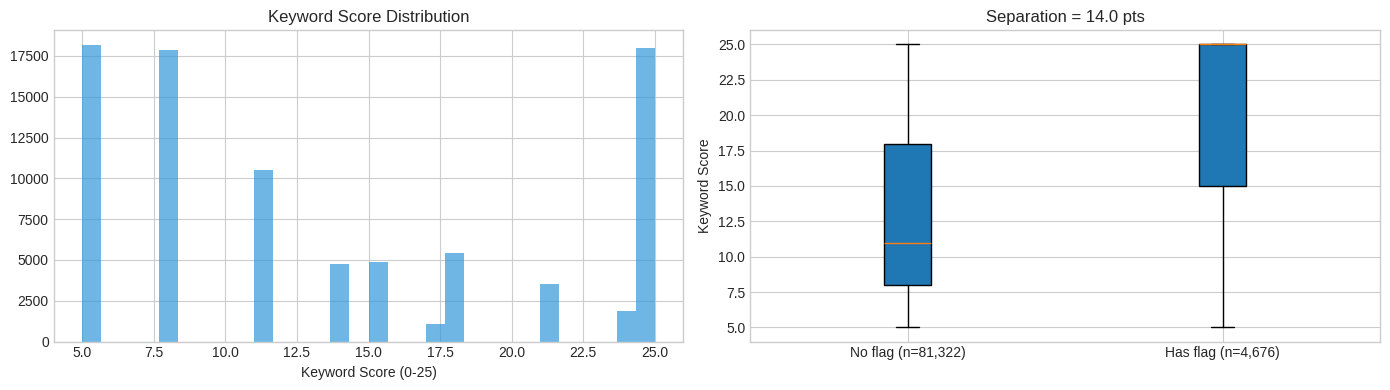

All required Section 3 columns confirmed. Saved -> complaints_scored.csv


In [24]:
# 3.5 Keyword score validation chart + Section 3 checkpoint save
flagged     = (df_complaints[['has_crash','has_injury','has_fatality','has_fire']] == 1).any(axis=1)
kw_no_flag  = df_complaints[~flagged]['keyword_score']
kw_has_flag = df_complaints[flagged]['keyword_score']
separation  = kw_has_flag.median() - kw_no_flag.median()

print(f'Keyword score -- No flag:  median={kw_no_flag.median():.1f}')
print(f'Keyword score -- Has flag: median={kw_has_flag.median():.1f}')
print(f'Separation: {separation:.1f} pts  ({"good" if separation > 5 else "check keyword tiers"})')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df_complaints['keyword_score'], bins=30, color='#3498db', alpha=0.7)
axes[0].set_xlabel('Keyword Score (0-25)')
axes[0].set_title('Keyword Score Distribution')
axes[1].boxplot([kw_no_flag, kw_has_flag],
    labels=[f'No flag (n={len(kw_no_flag):,})', f'Has flag (n={len(kw_has_flag):,})'],
    patch_artist=True)
axes[1].set_ylabel('Keyword Score')
axes[1].set_title(f'Separation = {separation:.1f} pts')
plt.tight_layout()
plt.savefig(drive_path('data/outputs/keyword_score_validation.png'), dpi=150, bbox_inches='tight')
plt.show()

# Save checkpoint
df_complaints.to_csv(drive_path('data/processed/complaints_scored.csv'), index=False)
required = ['text_clean','has_crash','has_fire','has_injury','has_fatality',
            'component_risk','keyword_score','keywords_found']
missing = [c for c in required if c not in df_complaints.columns]
if missing: print(f'WARNING - Missing columns: {missing}')
else:       print('All required Section 3 columns confirmed. Saved -> complaints_scored.csv')

## spaCy NER for component and Failure mode extraction
- The complaint text often mentions specific components the structured field misses.
- is possible to train a custom NER on NHTSA corpus ?

In [25]:
# Cell 3.6 — NER-based component extraction
import spacy
nlp = spacy.load('en_core_web_sm')

def extract_failure_entities(text):
    doc = nlp(text)
    components = [ent.text for ent in doc.ents if ent.label_ in ('PRODUCT', 'ORG')]
    # Automotive pattern matching for component mentions
    component_patterns = [
        r'\b(brake|steering|airbag|engine|transmission|throttle|fuel)\s*(system|pump|pedal|wheel|column|module)?\b',
        r'\b(abs|ecu|pcm|bcm|tcm)\b',
    ]
    for pattern in component_patterns:
        matches = re.findall(pattern, text.lower())
        components.extend([' '.join(m).strip() for m in matches])
    return list(set(components))

---
## Section 4 - ML-Based Scoring (0-75 pts)
> **Scoring Architecture -- Tier 2 of 2 (ML ensemble contribution)**

> The ML ensemble contributes the remaining **75 points** of the composite.
> Split across three independently interpretable sub-signals:

> | Sub-signal | Range | Model / Source |
> |---|---|---|
> | **Score-A** -- Defect severity (text) | 0-25 | TF-IDF + Logistic Regression prob |
> | **Score-B** -- Incident severity (structured) | 0-25 | Weighted structured flag formula |
> | **Score-C** -- Classification confidence | 0-25 | Zero-shot confidence + cluster coherence |
> | **ML ensemble total** | **0-75** | A + B + C (clipped) |

> `composite_score = keyword_score (0-25) + ml_ensemble_score (0-75)` -- max 100


In [26]:
# 4.0 Reload
df_complaints = pd.read_csv(drive_path('data/processed/complaints_scored.csv'))
df_recalls    = pd.read_csv(drive_path('data/raw/recalls_raw.csv'))
TEXT_COL      = 'text_clean'
required = ['text_clean','has_crash','has_fire','has_injury','has_fatality','component_risk','keyword_score']
missing  = [c for c in required if c not in df_complaints.columns]
if missing:
    raise FileNotFoundError(f'Missing columns: {missing} -- re-run Section 3 first.')
print(f'Loaded {len(df_complaints):,} complaints -- all signal columns confirmed')


Loaded 85,998 complaints -- all signal columns confirmed


In [27]:
# 4.1 Create silver training labels (weak supervision)
# Crash/injury/fatality/fire flags -> CRITICAL (1)
# Low keyword + low component risk + no flags -> NON-CRITICAL (0)
# Everything else -> UNCERTAIN (excluded from training)

critical_mask = (
    (df_complaints['has_crash']    == 1) |
    (df_complaints['has_injury']   == 1) |
    (df_complaints['has_fatality'] == 1) |
    (df_complaints['has_fire']     == 1)
)

# CHANGED: keyword_score threshold 25 -> 15
# Original was < 25 which is the hard cap — too permissive.
# A complaint scoring 15-24 on keywords is not cleanly non-critical.
non_critical_mask = (
    (df_complaints['keyword_score']  < 15) &   # was < 25
    (df_complaints['component_risk'] < 40) &
    (~critical_mask)
)

df_critical     = df_complaints[critical_mask].copy();     df_critical['label']     = 1
df_non_critical = df_complaints[non_critical_mask].copy(); df_non_critical['label'] = 0

n_sample = min(len(df_non_critical), len(df_critical) * 3)
df_train = (
    pd.concat([df_critical, df_non_critical.sample(n_sample, random_state=42)])
    .sample(frac=1, random_state=42).reset_index(drop=True)
)

print('Silver label breakdown:')
print(f'  CRITICAL:     {len(df_critical):>6,}  ({len(df_critical)/len(df_complaints):.1%})')
print(f'  NON-CRITICAL: {len(df_non_critical):>6,}  ({len(df_non_critical)/len(df_complaints):.1%})')
print(f'  UNCERTAIN:    {len(df_complaints)-len(df_critical)-len(df_non_critical):>6,}  (excluded)')
print(f'Training set: {len(df_train):,}  (Critical rate: {df_train["label"].mean():.1%})')

X_text = df_train[TEXT_COL].fillna('').tolist()
y      = df_train['label'].tolist()


Silver label breakdown:
  CRITICAL:      4,676  (5.4%)
  NON-CRITICAL:  9,381  (10.9%)
  UNCERTAIN:    71,941  (excluded)
Training set: 14,057  (Critical rate: 33.3%)


In [28]:
# 4.2 Model comparison -- Naive Bayes / LogReg / LinearSVM (5-fold CV)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipelines = {
    'NaiveBayes (baseline)': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,1), sublinear_tf=True)),
        ('clf',   ComplementNB(alpha=0.1)),
    ]),
    'LogisticRegression': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=8000, ngram_range=(1,2), sublinear_tf=True)),
        ('clf',   LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000)),
    ]),
    'LinearSVM': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=8000, ngram_range=(1,2), sublinear_tf=True)),
        ('clf',   CalibratedClassifierCV(
            LinearSVC(C=1.0, class_weight='balanced', max_iter=2000), cv=3
        )),
    ]),
}

results = {}
print('Running 5-fold cross-validation...')
for name, pipeline in pipelines.items():
    scores = cross_val_score(pipeline, X_text, y, cv=cv, scoring='f1')
    results[name] = {'f1_mean': scores.mean(), 'f1_std': scores.std()}
    print(f'  {name}: F1 = {scores.mean():.3f} +/- {scores.std():.3f}')

best_model_name = max(results, key=lambda k: results[k]['f1_mean'])
print(f'Best model: {best_model_name}')


Running 5-fold cross-validation...
  NaiveBayes (baseline): F1 = 0.878 +/- 0.009
  LogisticRegression: F1 = 0.922 +/- 0.007
  LinearSVM: F1 = 0.932 +/- 0.006
Best model: LinearSVM


In [29]:
# 4.3 Train final classifier + inspect feature weights
X_train, X_test, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

final_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=8000, ngram_range=(1,2), sublinear_tf=True, min_df=2)),
    ('clf',   LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000)),
])
final_pipeline.fit(X_train, y_train)

y_pred = final_pipeline.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Non-Critical','Critical']))

feature_names = final_pipeline.named_steps['tfidf'].get_feature_names_out()
coefs         = final_pipeline.named_steps['clf'].coef_[0]
top_crit_idx  = np.argsort(coefs)[::-1][:15]
print('Top 15 terms -> CRITICAL:')
for i, idx in enumerate(top_crit_idx):
    print(f'  {i+1:2d}. "{feature_names[idx]}" (weight: {coefs[idx]:.3f})')

with open(drive_path('data/processed/final_pipeline.pkl'), 'wb') as f:
    pickle.dump(final_pipeline, f)
print('Model saved -> data/processed/final_pipeline.pkl')


              precision    recall  f1-score   support

Non-Critical       0.96      0.96      0.96      1877
    Critical       0.92      0.91      0.92       935

    accuracy                           0.95      2812
   macro avg       0.94      0.94      0.94      2812
weighted avg       0.95      0.95      0.95      2812

Top 15 terms -> CRITICAL:
   1. "fire" (weight: 9.519)
   2. "accident" (weight: 7.896)
   3. "hit" (weight: 5.679)
   4. "brake" (weight: 5.620)
   5. "smoke" (weight: 5.534)
   6. "collision" (weight: 5.421)
   7. "crash" (weight: 5.159)
   8. "injury" (weight: 4.719)
   9. "deploy" (weight: 4.320)
  10. "airbags" (weight: 4.056)
  11. "suddenly" (weight: 3.743)
  12. "airbag" (weight: 3.562)
  13. "flame" (weight: 3.540)
  14. "dangerous" (weight: 3.535)
  15. "steer" (weight: 3.388)
Model saved -> data/processed/final_pipeline.pkl


In [30]:
# 4.4 Compute three ML sub-scores (Score-A, Score-B, Score-C) -> ensemble (0-75)

# Score-A: Defect severity (0-25) -- from LR probability
all_texts = df_complaints[TEXT_COL].fillna('').tolist()
ml_proba  = final_pipeline.predict_proba(all_texts)[:, 1]
df_complaints['score_a_defect_severity'] = (ml_proba * 25).round(2)

# Score-B: Incident severity (0-25) -- from structured fields + component risk
def compute_incident_severity(row) -> float:
    score = 0.0
    score += min(row['has_fatality'] * 12.5, 25.0)
    if row['has_fatality'] == 0:
        deaths = float(row.get('numberOfDeaths', 0) or 0)
        score += min(deaths * 6.25, 12.5)
    score += min(row['has_injury'] * 2.5, 12.5)
    score += row['has_crash'] * 10.0
    score += row['has_fire']  * 8.0
    score += row.get('filed_quickly', 0) * 2.0

    # NEW: Component risk bonus (0-5 pts)
    # component_risk is on 0-95 scale. Normalise to 0-5 additive pts.
    # Only applied when no fatality (fatality already maxes Score-B).
    if row.get('has_fatality', 0) == 0:
        comp_risk = float(row.get('component_risk', 30) or 30)
        comp_bonus = min((comp_risk / 95) * 5.0, 5.0)
        score += comp_bonus

    return round(min(score, 25.0), 2)

df_complaints['score_b_incident_severity'] = df_complaints.apply(compute_incident_severity, axis=1)

# Score-C: Classification confidence (0-25)
# Pre-filled with ML confidence (0-12) only. Will be updated with full signal
# (zero-shot confidence + cluster coherence) at the end of Section 6.
df_complaints['score_c_confidence'] = (ml_proba * 12).round(2)

# ML ensemble (0-75)
df_complaints['ml_ensemble_score'] = (
    df_complaints['score_a_defect_severity'] +
    df_complaints['score_b_incident_severity'] +
    df_complaints['score_c_confidence']
).clip(0, 75).round(2)

# Final composite (0-100)
df_complaints['composite_score'] = (
    df_complaints['keyword_score'] +
    df_complaints['ml_ensemble_score']
).clip(0, 100).round(2)

print('Score component breakdown:')
for col, rng in [('keyword_score','0-25'),('ml_ensemble_score','0-75'),('composite_score','0-100')]:
    s = df_complaints[col]
    print(f'  {col:<30} mean={s.mean():.1f}  median={s.median():.1f}  range={rng}')


Score component breakdown:
  keyword_score                  mean=13.6  median=11.0  range=0-25
  ml_ensemble_score              mean=19.6  median=17.0  range=0-75
  composite_score                mean=33.3  median=30.0  range=0-100


In [31]:
# 4.5 Derive SBERT threshold + validate composite separation
flagged         = (df_complaints[['has_crash','has_injury','has_fatality','has_fire']] == 1).any(axis=1)
no_flag_scores  = df_complaints[~flagged]['composite_score']
has_flag_scores = df_complaints[flagged]['composite_score']
separation      = has_flag_scores.median() - no_flag_scores.median()

# Derive natural valley threshold for SBERT subsetting
scores           = df_complaints['composite_score'].values
hist, bin_edges  = np.histogram(scores, bins=100)
mid_mask         = (bin_edges[:-1] >= 25) & (bin_edges[:-1] <= 65)
SBERT_THRESHOLD  = round(float(bin_edges[:-1][mid_mask][hist[mid_mask].argmin()]), 1)

print('Final composite distribution:')
print(df_complaints['composite_score'].describe().round(1))
print(f'Separation: {separation:.1f} pts  ({"good" if separation > 20 else "check weights"})')
print(f'SBERT threshold (natural valley): {SBERT_THRESHOLD}')

import json
with open(drive_path('data/processed/scoring_config.json'), 'w') as f:
    json.dump({
        'sbert_threshold':      SBERT_THRESHOLD,
        'composite_score_mean': round(df_complaints['composite_score'].mean(), 1),
        'composite_score_std':  round(df_complaints['composite_score'].std(),  1),
        'flagged_pct':          round(float(flagged.mean()), 4),
        'n_complaints':         len(df_complaints),
    }, f, indent=2)

df_complaints.to_csv(drive_path('data/processed/complaints_scored.csv'), index=False)
print('Saved scoring_config.json + complaints_scored.csv')


Final composite distribution:
count    85998.0
mean        33.3
std         16.3
min          6.8
25%         20.2
50%         30.0
75%         43.8
max         87.0
Name: composite_score, dtype: float64
Separation: 43.1 pts  (good)
SBERT threshold (natural valley): 64.5
Saved scoring_config.json + complaints_scored.csv


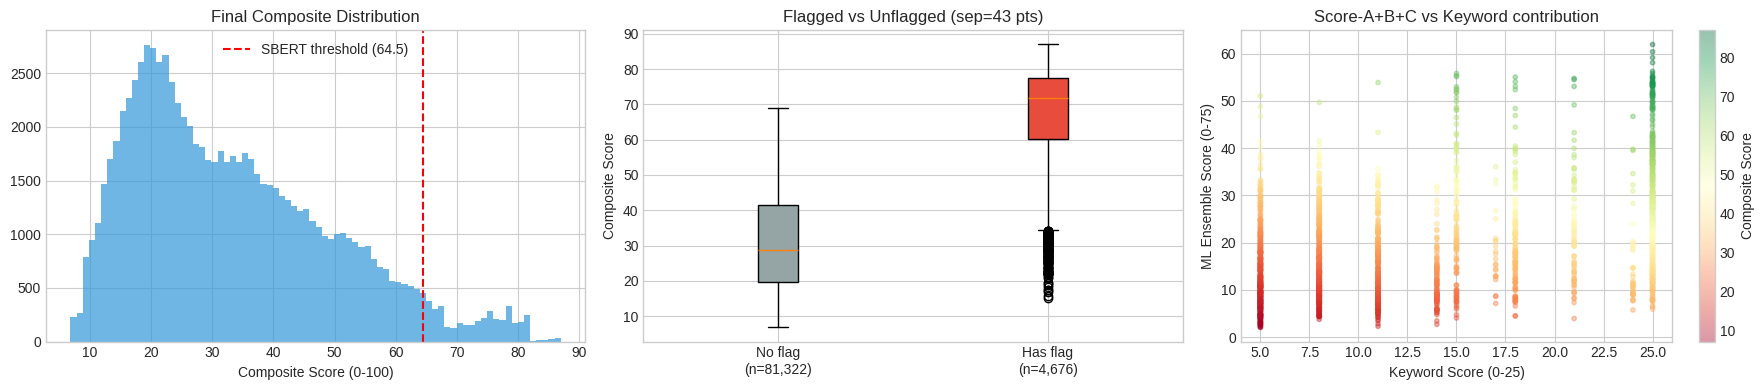

In [32]:
# 4.6 Composite distribution plot
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(df_complaints['composite_score'], bins=80, color='#3498db', alpha=0.7)
axes[0].axvline(SBERT_THRESHOLD, color='red', linestyle='--', label=f'SBERT threshold ({SBERT_THRESHOLD})')
axes[0].set_xlabel('Composite Score (0-100)')
axes[0].set_title('Final Composite Distribution')
axes[0].legend()

bp = axes[1].boxplot([no_flag_scores, has_flag_scores],
    labels=[f'No flag\n(n={len(no_flag_scores):,})', f'Has flag\n(n={len(has_flag_scores):,})'],
    patch_artist=True)
bp['boxes'][0].set_facecolor('#95a5a6')
bp['boxes'][1].set_facecolor('#e74c3c')
axes[1].set_ylabel('Composite Score')
axes[1].set_title(f'Flagged vs Unflagged (sep={separation:.0f} pts)')

sample = df_complaints.sample(min(2000, len(df_complaints)), random_state=42)
sc = axes[2].scatter(sample['keyword_score'], sample['ml_ensemble_score'],
    c=sample['composite_score'], cmap='RdYlGn', alpha=0.4, s=10)
plt.colorbar(sc, ax=axes[2], label='Composite Score')
axes[2].set_xlabel('Keyword Score (0-25)')
axes[2].set_ylabel('ML Ensemble Score (0-75)')
axes[2].set_title('Score-A+B+C vs Keyword contribution')

plt.tight_layout()
plt.savefig(drive_path('data/outputs/final_composite_audit.png'), dpi=150, bbox_inches='tight')
plt.show()


In [33]:
# 4.7 Temporal anomaly detection — per-vehicle complaint volume/severity spikes
# Isolation Forest flags months where complaint volume or severity is anomalous.
# This directly tests the "complaints precede recalls" hypothesis:
# a sudden spike in high-scoring complaints is the strongest early warning pattern.

from sklearn.ensemble import IsolationForest

def detect_vehicle_temporal_anomaly(vehicle_group: pd.DataFrame) -> dict:
    '''
    Returns temporal_anomaly (0/1) and anomaly_score (continuous, higher=more anomalous)
    for the most recent period in this vehicle's complaint history.
    '''
    group = vehicle_group.copy()
    group['complaint_date'] = pd.to_datetime(group.get('dateComplaintFiled', pd.NaT), errors='coerce')
    group = group.dropna(subset=['complaint_date'])

    if len(group) < 8:
        return {'temporal_anomaly': 0, 'anomaly_score': 0.0}

    group['month'] = group['complaint_date'].dt.to_period('M')
    monthly = group.groupby('month').agg(
        volume=('composite_score', 'count'),
        severity=('composite_score', 'mean'),
        crash_vol=('has_crash', 'sum'),
    ).reset_index()

    if len(monthly) < 4:
        return {'temporal_anomaly': 0, 'anomaly_score': 0.0}

    features = monthly[['volume', 'severity', 'crash_vol']].fillna(0).values
    iso = IsolationForest(contamination=0.15, random_state=42, n_estimators=50)
    iso.fit(features)
    preds  = iso.predict(features)
    scores = iso.decision_function(features)

    # Anomaly status and score for the MOST RECENT month
    latest_anomaly = int(preds[-1] == -1)
    latest_score   = round(float(-scores[-1]), 4)  # Invert: higher = more anomalous

    return {'temporal_anomaly': latest_anomaly, 'anomaly_score': latest_score}

df_complaints_for_anomaly = pd.read_csv(drive_path('data/processed/complaints_scored.csv'))
df_complaints_for_anomaly['vehicle_key'] = (
    df_complaints_for_anomaly['make_pulled'].str.upper() + '_' +
    df_complaints_for_anomaly['model_pulled'].str.upper() + '_' +
    df_complaints_for_anomaly['year_pulled'].astype(str)
)

print('Running temporal anomaly detection per vehicle...')
anomaly_results = (
    df_complaints_for_anomaly.groupby('vehicle_key', group_keys=False)
    .apply(detect_vehicle_temporal_anomaly)
)
df_anomaly = pd.DataFrame(list(anomaly_results), index=anomaly_results.index).reset_index()
df_anomaly.columns = ['vehicle_key', 'temporal_anomaly', 'anomaly_score']
df_anomaly.to_csv(drive_path('data/processed/vehicle_temporal_anomaly.csv'), index=False)

n_anomalous = df_anomaly['temporal_anomaly'].sum()
print(f'Anomaly detection complete:')
print(f'  Vehicles flagged as anomalous (latest month): {n_anomalous} ({n_anomalous/len(df_anomaly):.0%})')
print(f'  Mean anomaly score (flagged): {df_anomaly[df_anomaly["temporal_anomaly"]==1]["anomaly_score"].mean():.3f}')
print('Saved -> data/processed/vehicle_temporal_anomaly.csv')
print('NOTE: Merge into df_vehicles_v2 in Cell 7.1 (see vehicle feature function update below)')

Running temporal anomaly detection per vehicle...
Anomaly detection complete:
  Vehicles flagged as anomalous (latest month): 35 (11%)
  Mean anomaly score (flagged): 0.073
Saved -> data/processed/vehicle_temporal_anomaly.csv
NOTE: Merge into df_vehicles_v2 in Cell 7.1 (see vehicle feature function update below)


---
## Section 5 - SBERT Semantic Clustering
> **NLP Concept:** Sentence embeddings + density-based unsupervised clustering.

> SBERT converts each complaint into a 384-dim vector encoding *meaning*, not word frequency.
> Two complaints describing the same brake failure with different vocabulary:
> - TF-IDF cosine similarity: ~0.08 (nearly zero)
> - SBERT cosine similarity:  ~0.81 (strongly similar)

> HDBSCAN discovers cluster count from data density -- no need to pre-specify k.


In [34]:
# 5.0 Reload + load scoring config
import json
import hdbscan
import umap
from sentence_transformers import SentenceTransformer

df = pd.read_csv(drive_path('data/processed/complaints_scored.csv'))
df['text_clean'] = df['text_clean'].fillna('')

with open(drive_path('data/processed/scoring_config.json')) as f:
    scoring_config = json.load(f)

SBERT_THRESHOLD = scoring_config['sbert_threshold']
print(f'Loaded {len(df):,} scored complaints')
print(f'Composite range: {df["composite_score"].min():.1f} - {df["composite_score"].max():.1f}')
print(f'SBERT threshold: {SBERT_THRESHOLD}')


Loaded 85,998 scored complaints
Composite range: 6.8 - 87.0
SBERT threshold: 64.5


In [35]:
# 5.1 TF-IDF vs SBERT demonstration
pair_A = 'the steering wheel became unresponsive at 60mph vehicle drifted into adjacent lane'
pair_B = 'lost control of car direction on highway wheel would not respond to input'
pair_C = 'bluetooth audio not connecting to phone after software update'

vec = TfidfVectorizer()
X   = vec.fit_transform([pair_A, pair_B, pair_C])
print('TF-IDF similarities:')
print(f'  A vs B (same defect, different words): {cosine_similarity(X[0], X[1])[0][0]:.3f}')
print(f'  A vs C (completely different topic):   {cosine_similarity(X[0], X[2])[0][0]:.3f}')

print('Loading SBERT model (~80MB first time)...')
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')
demo_emb    = sbert_model.encode([pair_A, pair_B, pair_C])
print('SBERT similarities:')
print(f'  A vs B (same defect, different words): {cosine_similarity([demo_emb[0]], [demo_emb[1]])[0][0]:.3f}')
print(f'  A vs C (completely different topic):   {cosine_similarity([demo_emb[0]], [demo_emb[2]])[0][0]:.3f}')
print('SBERT correctly identifies same-defect complaints as semantically similar.')


TF-IDF similarities:
  A vs B (same defect, different words): 0.050
  A vs C (completely different topic):   0.000
Loading SBERT model (~80MB first time)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

SBERT similarities:
  A vs B (same defect, different words): 0.517
  A vs C (completely different topic):   0.062
SBERT correctly identifies same-defect complaints as semantically similar.


In [36]:
# 5.2 Generate embeddings -- ALL complaints (full pipeline pass)
# MiniLM-L6-v2 encodes ~1000 docs/sec on T4 → ~90 sec for 86K corpus.
# Previous version embedded only high-score subset (~3500 complaints).
# Consequence of partial embedding: sbert_cluster_rate feature was near-zero
# for 96% of vehicles, making that term in the risk score effectively dead.

import torch

print(f'Embedding ALL {len(df):,} complaints (full pipeline pass)...')
embeddings_all = sbert_model.encode(
    df['text_clean'].tolist(),
    batch_size=256,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
    device='cuda' if torch.cuda.is_available() else 'cpu',
)
np.save(drive_path('data/processed/embeddings_all.npy'), embeddings_all)
print(f'Embeddings saved  |  shape: {embeddings_all.shape}  ({len(df):,} x 384-dim)')

# Keep high-score reference subset for legacy variable compatibility
HIGH_SCORE_MASK = df['composite_score'] >= SBERT_THRESHOLD
df_high = df[HIGH_SCORE_MASK].copy().reset_index(drop=True)
embeddings_high = embeddings_all[HIGH_SCORE_MASK.values]

# Low-score sample for visualisation contrast (same as before)
LOW_SCORE_MASK  = df['composite_score'] < 30
df_low_sample   = df[LOW_SCORE_MASK].sample(min(200, LOW_SCORE_MASK.sum()), random_state=42)
embeddings_low  = embeddings_all[LOW_SCORE_MASK.values][:len(df_low_sample)]

np.save(drive_path('data/processed/embeddings_high.npy'), embeddings_high)
np.save(drive_path('data/processed/embeddings_low.npy'),  embeddings_low)
df_high.to_csv(drive_path('data/processed/complaints_high_score.csv'), index=False)
print(f'High-score subset: {len(df_high):,} complaints  |  embeddings_high shape: {embeddings_high.shape}')

Embedding ALL 85,998 complaints (full pipeline pass)...


Batches:   0%|          | 0/336 [00:00<?, ?it/s]

Embeddings saved  |  shape: (85998, 384)  (85,998 x 384-dim)
High-score subset: 4,109 complaints  |  embeddings_high shape: (4109, 384)


In [37]:
# 5.3 UMAP (384D -> 2D) + HDBSCAN clustering -- full corpus parameters
print('Step 1: UMAP dimensionality reduction (384D -> 2D) on high-score subset...')
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine',
    random_state=42,
    verbose=False,
)
embeddings_2d = reducer.fit_transform(embeddings_high)
print(f'  2D projection shape: {embeddings_2d.shape}')

print('Step 2: HDBSCAN density-based clustering...')
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=25,          # Fixed (was: max(5, len//50) — breaks on large N)
    min_samples=5,                # Unchanged
    metric='euclidean',
    cluster_selection_method='eom',          # Added: more stable than default 'leaf'
    cluster_selection_epsilon=0.0,           # Let HDBSCAN decide naturally
)
cluster_labels = clusterer.fit_predict(embeddings_2d)
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise    = (cluster_labels == -1).sum()
print(f'  Clusters found:   {n_clusters}')
print(f'  Noise (outliers): {n_noise}  ({n_noise/len(df_high):.0%})')

df_high = df_high.copy()
df_high['sbert_cluster'] = cluster_labels
df_high['umap_x']        = embeddings_2d[:, 0]
df_high['umap_y']        = embeddings_2d[:, 1]

Step 1: UMAP dimensionality reduction (384D -> 2D) on high-score subset...
  2D projection shape: (4109, 2)
Step 2: HDBSCAN density-based clustering...
  Clusters found:   32
  Noise (outliers): 326  (8%)


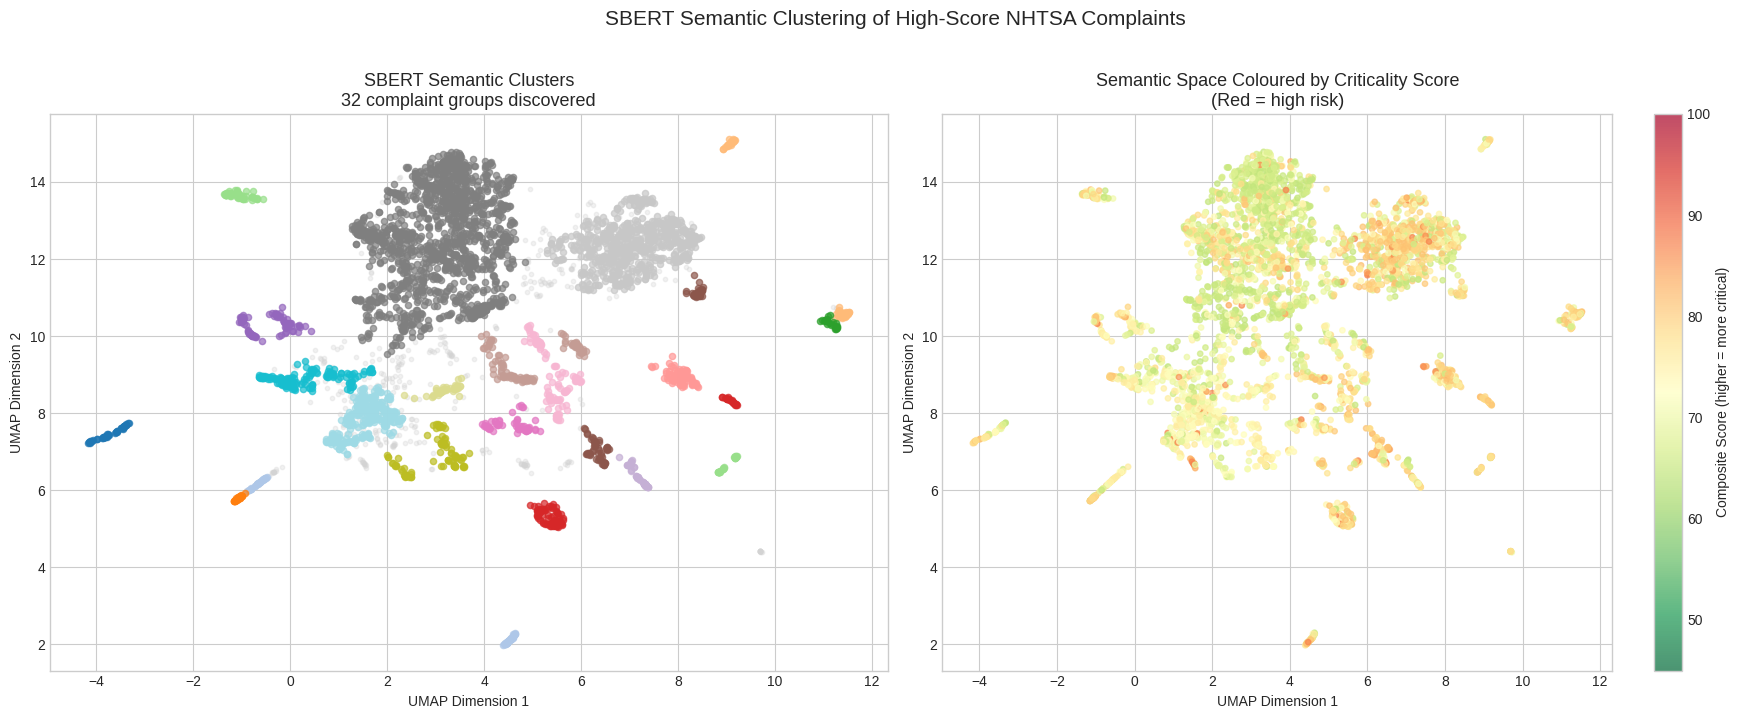

In [38]:
# 5.4 Cluster visualisation (side-by-side: cluster labels | criticality score)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
palette = cm.get_cmap('tab20', max(len(set(cluster_labels)), 1))

ax1 = axes[0]
for i, cid in enumerate(sorted(set(cluster_labels))):
    mask  = cluster_labels == cid
    label = f'Cluster {cid}' if cid != -1 else 'Noise'
    color = 'lightgray' if cid == -1 else palette(i)
    ax1.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1],
                c=[color], label=label,
                s=20 if cid != -1 else 10, alpha=0.7 if cid != -1 else 0.3)
ax1.set_title(f'SBERT Semantic Clusters\n{n_clusters} complaint groups discovered', fontsize=13)
ax1.set_xlabel('UMAP Dimension 1'); ax1.set_ylabel('UMAP Dimension 2')
if n_clusters <= 10: ax1.legend(loc='upper right', fontsize=8)

ax2 = axes[1]
sc = ax2.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
    c=df_high['composite_score'].values, cmap='RdYlGn_r',
    s=15, alpha=0.7, vmin=45, vmax=100)
plt.colorbar(sc, ax=ax2, label='Composite Score (higher = more critical)')
ax2.set_title('Semantic Space Coloured by Criticality Score\n(Red = high risk)', fontsize=13)
ax2.set_xlabel('UMAP Dimension 1'); ax2.set_ylabel('UMAP Dimension 2')

plt.suptitle('SBERT Semantic Clustering of High-Score NHTSA Complaints', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(drive_path('data/outputs/sbert_clusters.png'), dpi=150, bbox_inches='tight')
plt.show()

In [39]:
# 5.5 Cluster inspection -- validate that clusters match real defect modes
print('CLUSTER INSPECTION -- What did SBERT group together?')
print('Key question: do clusters match real defect modes without labels?')
for cluster_id in sorted(set(cluster_labels)):
    if cluster_id == -1: continue
    mask    = df_high['sbert_cluster'] == cluster_id
    subset  = df_high[mask]
    crash   = subset.get('has_crash',  pd.Series([0]*len(subset))).mean()
    injury  = subset.get('has_injury', pd.Series([0]*len(subset))).mean()
    print(f'\nCLUSTER {cluster_id} ({mask.sum()} complaints)')
    print(f'  Mean composite score : {subset["composite_score"].mean():.1f}')
    print(f'  Crash rate           : {crash:.0%}')
    print(f'  Injury rate          : {injury:.0%}')
    print('  Sample complaints:')
    for _, row in subset.nlargest(2, 'composite_score').iterrows():
        print(f'    [{row.get("make_pulled","?")} {row.get("model_pulled","?")}]')
        print(f'    Score {row["composite_score"]:.0f}: {str(row.get("summary",""))[:160]}')
    if cluster_id >= 5:
        print(f'... ({n_clusters - 6} more clusters)')
        break


CLUSTER INSPECTION -- What did SBERT group together?
Key question: do clusters match real defect modes without labels?

CLUSTER 0 (54 complaints)
  Mean composite score : 73.4
  Crash rate           : 26%
  Injury rate          : 22%
  Sample complaints:
    [VOLVO XC90 T8]
    Score 81: The contact owns a 2016 VOLVO XC90. The contact stated that while coming off a red light at 10 MPH, the contact was involved in a vehicle accident. The front en
    [VOLVO XC90 T6]
    Score 81: The contact owns a 2016 VOLVO XC90. The contact stated that while coming off a red light at 10 MPH, the contact was involved in a vehicle accident. The front en

CLUSTER 1 (47 complaints)
  Mean composite score : 75.7
  Crash rate           : 85%
  Injury rate          : 49%
  Sample complaints:
    [CHEVROLET MALIBU]
    Score 87: Officer [XXX] filed on behalf of the deceased. The deceased owned a 2020 Chevrolet Malibu. The contact stated that the deceased had a rear end crash with anothe
    [CHEVROLET MALIBU

In [40]:
# 5.6 Semantic similarity search + cluster size features
def find_similar_complaints(query_text, df_ref, ref_embeddings, model, top_k=5):
    query_emb    = model.encode([query_text], convert_to_numpy=True, normalize_embeddings=True)
    similarities = np.dot(ref_embeddings, query_emb.T).flatten()
    top_indices  = np.argsort(similarities)[::-1][:top_k]
    result       = df_ref.iloc[top_indices].copy()
    result['similarity'] = similarities[top_indices]
    return result[['make_pulled','model_pulled','year_pulled','composite_score','similarity','summary']].head(top_k)

TEST_QUERY = 'vehicle suddenly veered right without steering input, nearly caused accident'
print(f'Query: "{TEST_QUERY}"')
similar = find_similar_complaints(TEST_QUERY, df_high, embeddings_high, sbert_model)
for i, (_, row) in enumerate(similar.iterrows()):
    print(f'  {i+1}. [{row.get("make_pulled","?")} {row.get("model_pulled","?")}]  '
          f'sim={row["similarity"]:.3f}  score={row.get("composite_score","?"):.0f}')
    print(f'     {str(row.get("summary",""))[:160]}')

# Cluster size as feature: large cluster = same defect reported repeatedly
df_high['sbert_cluster_size'] = df_high['sbert_cluster'].map(df_high['sbert_cluster'].value_counts()).fillna(1)
df_high['sbert_is_clustered'] = (df_high['sbert_cluster'] != -1).astype(int)
df_high.to_csv(drive_path('data/processed/complaints_high_score_clustered.csv'), index=False)
print(f'Cluster features added. {df_high["sbert_is_clustered"].mean():.0%} complaints in a cluster.')


Query: "vehicle suddenly veered right without steering input, nearly caused accident"
  1. [TOYOTA RAV4]  sim=0.598  score=78
     Steering suddenly locked up. Car steered to the right went off the road. Turned over several times and landed upside down.  Causing serious injuries to myself a
  2. [GMC ACADIA]  sim=0.547  score=66
     While operating my vehicle, the power steering suddenly failed without adequate warning. The steering became extremely difficult, creating a significant safety 
  3. [NISSAN ALTIMA]  sim=0.529  score=78
     While driving straight on a two lane road, steering wheel suddenly locked, unable to regain control the car was locked in a turning position causing the vehicle
  4. [CHRYSLER PACIFICA]  sim=0.518  score=66
     Several near-accidents yesterday and today. Steering wheel randomly locks up when driving. This is an extremely dangerous situation for my wife and 4 children r
  5. [FORD F-150 REGULAR CAB]  sim=0.514  score=66
     STEERING WENT OUT SUDDENLY 

In [41]:
# 5.7 Cross-vehicle defect pattern matching
# Identifies SBERT clusters that span multiple makes/models.
# These indicate shared-supplier or shared-platform defects.
# Example: Takata airbag recall spread across 19 manufacturers.
# A cross-vehicle cluster flag is a strong early recall predictor.

CROSS_VEHICLE_MIN_MAKES = 3  # Min distinct makes to flag as cross-vehicle

df_high_cv = df_high.copy()
df_high_cv['cross_vehicle_flag'] = 0
df_high_cv['cross_vehicle_makes'] = 0

cross_vehicle_clusters = []

for cluster_id in sorted(set(cluster_labels)):
    if cluster_id == -1:
        continue

    mask        = df_high_cv['sbert_cluster'] == cluster_id
    cluster_sub = df_high_cv[mask]
    n_makes     = cluster_sub['make_pulled'].nunique()
    n_models    = cluster_sub['vehicle_key'].nunique() if 'vehicle_key' in cluster_sub else 0

    if n_makes >= CROSS_VEHICLE_MIN_MAKES:
        df_high_cv.loc[mask, 'cross_vehicle_flag']  = 1
        df_high_cv.loc[mask, 'cross_vehicle_makes'] = n_makes
        cross_vehicle_clusters.append({
            'cluster_id':     cluster_id,
            'n_complaints':   mask.sum(),
            'n_makes':        n_makes,
            'makes':          sorted(cluster_sub['make_pulled'].unique().tolist()),
            'mean_score':     round(cluster_sub['composite_score'].mean(), 1),
        })

print(f'Cross-vehicle analysis complete:')
print(f'  Total clusters:              {n_clusters}')
print(f'  Cross-vehicle clusters (>={CROSS_VEHICLE_MIN_MAKES} makes): {len(cross_vehicle_clusters)}')
if cross_vehicle_clusters:
    for cv in sorted(cross_vehicle_clusters, key=lambda x: -x['n_makes']):
        print(f'  Cluster {cv["cluster_id"]:2d}: {cv["n_makes"]} makes, '
              f'{cv["n_complaints"]} complaints, mean_score={cv["mean_score"]}')
        print(f'    Makes: {", ".join(cv["makes"][:6])}{"..." if len(cv["makes"]) > 6 else ""}')

# Save cluster-level cross-vehicle metadata
df_cv_clusters = pd.DataFrame(cross_vehicle_clusters) if cross_vehicle_clusters else pd.DataFrame()
if len(df_cv_clusters) > 0:
    df_cv_clusters.to_csv(drive_path('data/outputs/cross_vehicle_clusters.csv'), index=False)

# Save updated df_high with cross_vehicle_flag
df_high_cv.to_csv(drive_path('data/processed/complaints_high_score_clustered.csv'), index=False)
print('Updated complaints_high_score_clustered.csv with cross_vehicle_flag')

Cross-vehicle analysis complete:
  Total clusters:              32
  Cross-vehicle clusters (>=3 makes): 15
  Cluster 22: 31 makes, 1415 complaints, mean_score=69.6
    Makes: ACURA, AUDI, BMW, BUICK, CADILLAC, CAN-AM...
  Cluster 24: 27 makes, 613 complaints, mean_score=75.7
    Makes: ACURA, AUDI, BMW, BUICK, CADILLAC, CHEVROLET...
  Cluster 31: 24 makes, 202 complaints, mean_score=72.7
    Makes: ACURA, BMW, BUICK, CADILLAC, CHEVROLET, CHRYSLER...
  Cluster 30: 19 makes, 78 complaints, mean_score=73.3
    Makes: ACURA, CADILLAC, CHEVROLET, CHRYSLER, DODGE, FORD...
  Cluster 23: 16 makes, 48 complaints, mean_score=75.4
    Makes: BUICK, CHEVROLET, DODGE, FORD, GMC, HONDA...
  Cluster 16: 14 makes, 37 complaints, mean_score=74.9
    Makes: AUDI, CHEVROLET, CHRYSLER, DODGE, FORD, HONDA...
  Cluster 29: 11 makes, 45 complaints, mean_score=72.6
    Makes: AUDI, BMW, FORD, HYUNDAI, KIA, LINCOLN...
  Cluster 25: 9 makes, 67 complaints, mean_score=74.3
    Makes: CHEVROLET, FIAT, FORD, GMC,

---
## Section 6 - Zero-Shot Defect Classification
> **NLP Concept:** NLI-based zero-shot classification (no labelled training data required).

> Uses `facebook/bart-large-mnli`. For each complaint, it tests whether the text
> *entails* each candidate category description. The highest entailment probability wins.

> This cell also **completes Score-C (0-25)** by adding zero-shot confidence + cluster
> coherence to the ML ensemble score.


In [42]:
# 6.0 Load zero-shot model
import torch
from transformers import pipeline as hf_pipeline

print('Loading zero-shot model (facebook/bart-large-mnli ~1.6GB first time)...')
zero_shot = hf_pipeline(
    'zero-shot-classification',
    model='facebook/bart-large-mnli',
    device=-1,   # -1 = CPU; change to 0 if T4 GPU active
)
print(f'Zero-shot model loaded  |  device: {zero_shot.device}')

# Reload on GPU if available
if str(zero_shot.device) == 'cpu' and torch.cuda.is_available():
    print('Reloading on GPU...')
    zero_shot = hf_pipeline('zero-shot-classification',
        model='facebook/bart-large-mnli', device=0, dtype=torch.float16)
    print(f'Pipeline now on: {zero_shot.device}')


Loading zero-shot model (facebook/bart-large-mnli ~1.6GB first time)...


config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.63GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

...

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Zero-shot model loaded  |  device: cpu
Reloading on GPU...


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

Pipeline now on: cuda:0


In [43]:
# 6.1 Define defect categories
# Category descriptions are the ONLY labels you provide -- no training data needed.
DEFECT_CATEGORIES = [
    'brake system failure or malfunction',
    'steering loss or unresponsive steering',
    'engine stall or unexpected shutdown',
    'airbag deployment failure or defect',
    'fuel system leak or failure',
    'electrical system fault or fire',
    'transmission or gearbox failure',
    'software glitch or electronic control unit error',
    'tire failure or blowout',
    'unintended acceleration or vehicle speed control issue',
    'structural defect or body integrity failure',
    'cosmetic or minor comfort issue',
]
CATEGORY_LABELS = [
    'BRAKE_SYSTEM','STEERING_LOSS','ENGINE_STALL','AIRBAG_DEFECT',
    'FUEL_SYSTEM','ELECTRICAL','TRANSMISSION','SOFTWARE_ECU',
    'TIRE_FAILURE','UNINTENDED_ACCEL','STRUCTURAL','COSMETIC',
]
CATEGORY_MAP = dict(zip(DEFECT_CATEGORIES, CATEGORY_LABELS))
SAFETY_CRITICAL_CATS = {
    'BRAKE_SYSTEM','STEERING_LOSS','ENGINE_STALL',
    'AIRBAG_DEFECT','FUEL_SYSTEM','UNINTENDED_ACCEL','ELECTRICAL',
}

# Demo on one complaint
test_text = ('while driving at 65mph the brake pedal went to the floor with no resistance, '
             'vehicle failed to decelerate, rear ended another car')
result = zero_shot(test_text, DEFECT_CATEGORIES, multi_label=False)
print('ZERO-SHOT DEMO:')
for label, score in zip(result['labels'][:5], result['scores'][:5]):
    print(f'  {CATEGORY_MAP.get(label, label):<20} {score:.3f}  {"#"*int(score*30)}')


ZERO-SHOT DEMO:
  UNINTENDED_ACCEL     0.464  #############
  BRAKE_SYSTEM         0.345  ##########
  STEERING_LOSS        0.083  ##
  ENGINE_STALL         0.037  #
  SOFTWARE_ECU         0.022  


In [44]:
# 6.2 Batched zero-shot classification
ZS_THRESHOLD = 65
BATCH_SIZE   = 32

df_high_clustered = pd.read_csv(drive_path('data/processed/complaints_high_score_clustered.csv'))
df_zs = df_high_clustered[df_high_clustered['composite_score'] >= ZS_THRESHOLD].copy()
if len(df_zs) > 2000:
    df_zs = df_zs.nlargest(2000, 'composite_score')

texts_to_classify = df_zs['text_clean'].fillna('').tolist()
indices           = df_zs.index.tolist()
valid_mask        = [len(t.split()) >= 8 for t in texts_to_classify]
valid_texts       = [t for t, v in zip(texts_to_classify, valid_mask) if v]
valid_indices     = [i for i, v in zip(indices, valid_mask) if v]
short_indices     = [i for i, v in zip(indices, valid_mask) if not v]

print(f'Texts to classify: {len(valid_texts)} valid, {len(short_indices)} too short')
print(f'Batch size: {BATCH_SIZE} -> {len(valid_texts) // BATCH_SIZE + 1} batches')
print(f'Estimated time: {(len(valid_texts) / BATCH_SIZE) * 1.5 / 60:.1f} minutes on T4')

def batch_zero_shot_with_progress(texts, indices, batch_size=32):
    results = []
    with tqdm(total=len(texts), desc='Zero-shot classifying', unit='complaint') as pbar:
        for i in range(0, len(texts), batch_size):
            batch_texts   = texts[i : i + batch_size]
            batch_indices = indices[i : i + batch_size]
            batch_out = zero_shot(batch_texts, DEFECT_CATEGORIES,
                multi_label=False, truncation=True, max_length=512)
            for idx, res in zip(batch_indices, batch_out):
                results.append({
                    'idx':            idx,
                    'zs_category':    CATEGORY_MAP.get(res['labels'][0], res['labels'][0]),
                    'zs_confidence':  round(res['scores'][0], 3),
                    'zs_second_cat':  CATEGORY_MAP.get(res['labels'][1], 'UNKNOWN') if len(res['labels']) > 1 else 'UNKNOWN',
                    'zs_second_conf': round(res['scores'][1], 3) if len(res['scores']) > 1 else 0.0,
                })
            pbar.update(len(batch_texts))
    return results

# Short texts -> UNKNOWN, valid texts -> classify
zs_results = [{'idx': i, 'zs_category': 'UNKNOWN', 'zs_confidence': 0.0,
               'zs_second_cat': 'UNKNOWN', 'zs_second_conf': 0.0} for i in short_indices]
zs_results.extend(batch_zero_shot_with_progress(valid_texts, valid_indices, BATCH_SIZE))
zs_results.sort(key=lambda x: x['idx'])
df_zs_results = pd.DataFrame(zs_results).set_index('idx')

# Initialize global zs_map_cat and zs_map_conf for KNN transfer and later use
global zs_map_cat
global zs_map_conf
zs_map_cat = df_zs_results['zs_category'].to_dict()
zs_map_conf = df_zs_results['zs_confidence'].to_dict()

print(f'Zero-shot complete -- {len(zs_results):,} complaints classified')
cat_counts = df_zs_results['zs_category'].value_counts()
for cat, count in cat_counts.items():
    print(f'  {cat:<22} {count:>4}  {"#"*int(count/cat_counts.max()*30)}')

Texts to classify: 1980 valid, 20 too short
Batch size: 32 -> 62 batches
Estimated time: 1.5 minutes on T4


Zero-shot classifying: 100%|██████████| 1980/1980 [09:35<00:00,  3.44complaint/s]

Zero-shot complete -- 2,000 complaints classified
  AIRBAG_DEFECT           741  ##############################
  BRAKE_SYSTEM            391  ###############
  UNINTENDED_ACCEL        305  ############
  ELECTRICAL              198  ########
  ENGINE_STALL            101  ####
  STEERING_LOSS            96  ###
  FUEL_SYSTEM              61  ##
  TRANSMISSION             32  #
  STRUCTURAL               28  #
  UNKNOWN                  20  
  TIRE_FAILURE             18  
  COSMETIC                  8  
  SOFTWARE_ECU              1  


In [45]:
# 6.2b KNN category transfer — extend zero-shot coverage to all complaints
# Zero-shot classified 2,000 complaints. Remaining ~84,000 get category via
# nearest-neighbor lookup in SBERT embedding space.
# Semantically similar complaints share defect category — this is the correct proxy.

from sklearn.neighbors import NearestNeighbors
from collections import Counter

print('Loading full embeddings for KNN transfer...')
embeddings_all_loaded = np.load(drive_path('data/processed/embeddings_all.npy'))
df_full_for_knn = pd.read_csv(drive_path('data/processed/complaints_scored.csv'))

# Build source: classified complaints with known categories
zs_cat_series   = pd.Series(zs_map_cat)    # {index: category} from Cell 6.2
zs_conf_series  = pd.Series(zs_map_conf)   # {index: confidence}

classified_indices   = list(zs_cat_series.index)
classified_cats      = zs_cat_series.values
classified_confs     = zs_conf_series.values
classified_embs      = embeddings_all_loaded[classified_indices]

# Unclassified indices
all_indices          = set(range(len(df_full_for_knn)))
unclassified_indices = sorted(all_indices - set(classified_indices))
unclassified_embs    = embeddings_all_loaded[unclassified_indices]

print(f'Classified (zero-shot)  : {len(classified_indices):,}')
print(f'Unclassified (KNN todo) : {len(unclassified_indices):,}')
print('Fitting KNN model on classified embeddings...')

# KNN with k=3: majority vote for robust category assignment
knn = NearestNeighbors(n_neighbors=3, metric='cosine', n_jobs=-1)
knn.fit(classified_embs)
distances, neighbor_indices = knn.kneighbors(unclassified_embs)

# Majority vote across 3 nearest classified neighbors
transferred_cats  = []
transferred_confs = []
for dist_row, idx_row in zip(distances, neighbor_indices):
    neighbor_cats = classified_cats[idx_row]
    vote = Counter(neighbor_cats).most_common(1)[0][0]
    # Confidence = similarity to nearest neighbour (1 - cosine_distance)
    conf = round(float(1.0 - dist_row[0]), 3)
    transferred_cats.append(vote)
    transferred_confs.append(conf)

# Write back to maps — KNN results get a confidence discount (max 0.6)
# to reflect that they are transfers, not direct classifications
for idx, cat, conf in zip(unclassified_indices, transferred_cats, transferred_confs):
    zs_map_cat[idx]  = cat
    zs_map_conf[idx] = min(conf * 0.6, 0.6)   # discounted confidence for KNN transfers

print(f'KNN transfer complete')
print('Category distribution across ALL complaints:')
all_cats = list(zs_map_cat.values())
for cat, count in Counter(all_cats).most_common():
    pct = count / len(all_cats) * 100
    print(f'  {cat:<22} {count:>6,}  ({pct:.1f}%)')

Loading full embeddings for KNN transfer...
Classified (zero-shot)  : 2,000
Unclassified (KNN todo) : 83,998
Fitting KNN model on classified embeddings...
KNN transfer complete
Category distribution across ALL complaints:
  AIRBAG_DEFECT          35,320  (41.1%)
  BRAKE_SYSTEM           16,269  (18.9%)
  UNINTENDED_ACCEL       15,072  (17.5%)
  ELECTRICAL              7,706  (9.0%)
  ENGINE_STALL            3,266  (3.8%)
  STEERING_LOSS           2,685  (3.1%)
  FUEL_SYSTEM             2,440  (2.8%)
  UNKNOWN                   859  (1.0%)
  TRANSMISSION              827  (1.0%)
  TIRE_FAILURE              614  (0.7%)
  STRUCTURAL                465  (0.5%)
  COSMETIC                  325  (0.4%)
  SOFTWARE_ECU              150  (0.2%)


In [46]:
# 6.3 Complete Score-C with zero-shot confidence + cluster coherence + category adjustment
df_zs = df_zs.join(df_zs_results, how='left')

def compute_score_c(row) -> float:
    '''
    0-25 confidence score:
      zs_score       (0-12): zero-shot confidence above 0.5 baseline
      cluster_score  (0-13): cluster coherence (repeated same defect)
      category_adj  (-10 to +6): safety-critical bonus / cosmetic penalty  ← NEW
    '''
    # Zero-shot confidence signal (unchanged)
    zs_conf  = row.get('zs_confidence', 0.5)
    zs_score = max(0, min((zs_conf - 0.5) * 24, 12))

    # Cluster coherence signal (unchanged)
    cluster_size = row.get('sbert_cluster_size', 0)
    if cluster_size >= 50:   cluster_score = 13
    elif cluster_size >= 20: cluster_score = 8
    elif cluster_size >= 5:  cluster_score = 4
    else:                    cluster_score = 1

    # NEW: Category-aware adjustment
    # Safety-critical categories earn a bonus; cosmetic complaints earn a penalty.
    # This creates proper score separation across defect types.
    category = row.get('zs_category', 'UNKNOWN')
    if category in SAFETY_CRITICAL_CATS:
        category_adj = +6     # BRAKE_SYSTEM, STEERING_LOSS, AIRBAG_DEFECT, etc.
    elif category == 'COSMETIC':
        category_adj = -10    # Pushes cosmetic complaints to 45-55 range
    elif category == 'UNKNOWN':
        category_adj = -2     # Mild penalty for unclassified
    else:
        category_adj = 0      # TRANSMISSION, STRUCTURAL — neutral

    total = zs_score + cluster_score + category_adj
    return round(min(max(total, 0.0), 25.0), 2)   # Clamp to 0-25

df_zs['score_c_confidence'] = df_zs.apply(compute_score_c, axis=1)
df_zs['ml_ensemble_score']  = (
    df_zs['score_a_defect_severity'] +
    df_zs['score_b_incident_severity'] +
    df_zs['score_c_confidence']
).clip(0, 75).round(2)
df_zs['composite_score'] = (
    df_zs['keyword_score'] + df_zs['ml_ensemble_score']
).clip(0, 100).round(2)

print('Score-C (confidence) distribution after zero-shot + category adjustment:')
print(df_zs['score_c_confidence'].describe().round(1))

# Validation: confirm category spread has improved
cat_score_check = df_zs.groupby('zs_category')['composite_score'].mean().sort_values()
print('\nCategory mean composite scores (should show >20 pt spread now):')
for cat, score in cat_score_check.items():
    print(f'  {cat:<22} {score:.1f}')

Score-C (confidence) distribution after zero-shot + category adjustment:
count    2000.0
mean       19.7
std         3.7
min         0.0
25%        19.0
50%        19.0
75%        22.4
max        25.0
Name: score_c_confidence, dtype: float64

Category mean composite scores (should show >20 pt spread now):
  COSMETIC               68.5
  SOFTWARE_ECU           74.0
  UNKNOWN                76.8
  TRANSMISSION           77.9
  TIRE_FAILURE           79.8
  STRUCTURAL             81.7
  FUEL_SYSTEM            82.6
  ENGINE_STALL           83.2
  ELECTRICAL             83.8
  STEERING_LOSS          85.6
  UNINTENDED_ACCEL       85.7
  BRAKE_SYSTEM           86.3
  AIRBAG_DEFECT          88.9


Category statistics (validation check):
                  count  mean_score
zs_category                        
AIRBAG_DEFECT       741       88.89
BRAKE_SYSTEM        391       86.27
UNINTENDED_ACCEL    305       85.71
STEERING_LOSS        96       85.58
ELECTRICAL          198       83.78
ENGINE_STALL        101       83.15
FUEL_SYSTEM          61       82.58
STRUCTURAL           28       81.66
TIRE_FAILURE         18       79.75
TRANSMISSION         32       77.93
UNKNOWN              20       76.79
SOFTWARE_ECU          1       73.96
COSMETIC              8       68.52


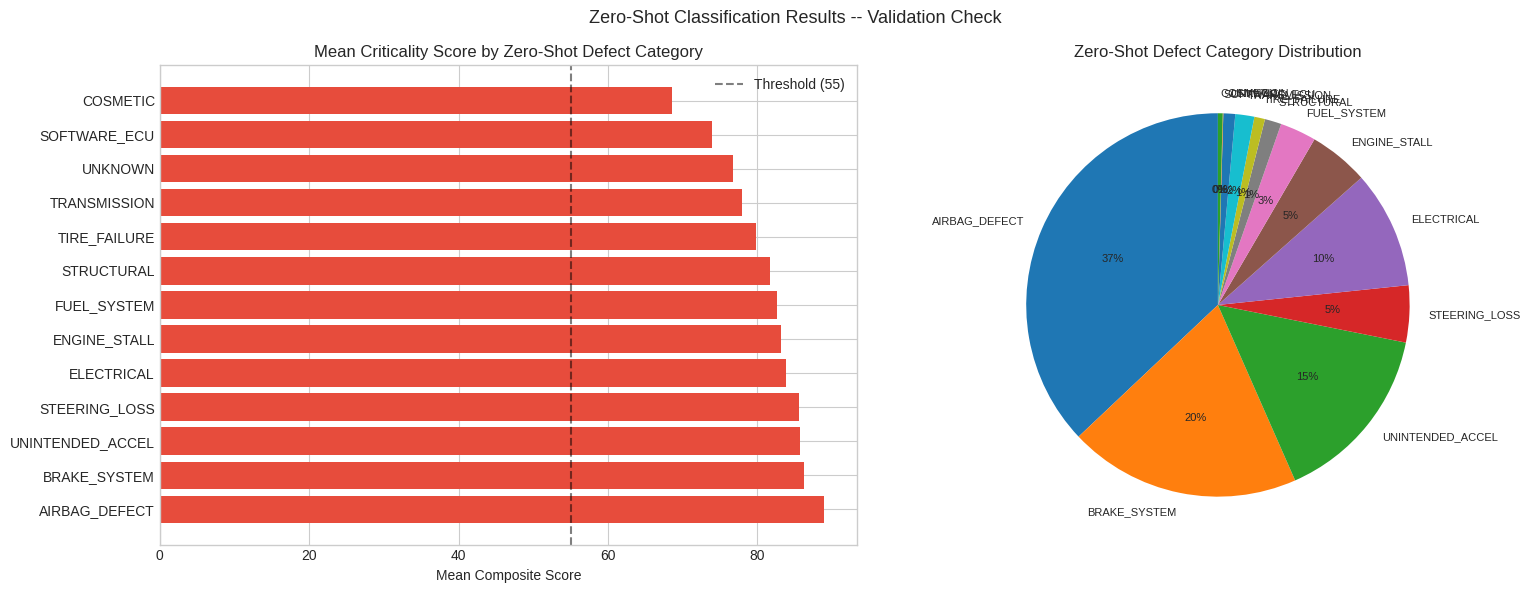

Interpretation: BRAKE_SYSTEM mean score >> COSMETIC -> zero-shot working correctly


In [47]:
# 6.4 Validation chart
cat_score_analysis = (
    df_zs.groupby('zs_category')
    .agg(count=('composite_score','count'), mean_score=('composite_score','mean'))
    .sort_values('mean_score', ascending=False).round(2)
)
print('Category statistics (validation check):')
print(cat_score_analysis.to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ['#e74c3c' if s > 65 else '#f39c12' if s > 50 else '#27ae60'
          for s in cat_score_analysis['mean_score']]
axes[0].barh(cat_score_analysis.index, cat_score_analysis['mean_score'], color=colors)
axes[0].axvline(55, color='black', linestyle='--', alpha=0.5, label='Threshold (55)')
axes[0].set_xlabel('Mean Composite Score')
axes[0].set_title('Mean Criticality Score by Zero-Shot Defect Category')
axes[0].legend()
axes[1].pie(cat_score_analysis['count'], labels=cat_score_analysis.index,
    autopct='%1.0f%%', startangle=90, textprops={'fontsize': 8})
axes[1].set_title('Zero-Shot Defect Category Distribution')
plt.suptitle('Zero-Shot Classification Results -- Validation Check', fontsize=13)
plt.tight_layout()
plt.savefig(drive_path('data/outputs/zero_shot_validation.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Interpretation: BRAKE_SYSTEM mean score >> COSMETIC -> zero-shot working correctly')


In [48]:
# 6.4b Near-duplicate complaint detection via cosine similarity
# NHTSA data includes: attorney-filed batches (same text, many vehicles),
# multi-filers (same person, slight variations), NHTSA template copy-paste.
# These inflate complaint volume signals without adding new information.
# Strategy: flag complaints with cosine similarity > 0.95 to any other complaint
# for the same vehicle_key.

from sklearn.neighbors import NearestNeighbors

print('Loading full embeddings for deduplication...')
embeddings_for_dedup = np.load(drive_path('data/processed/embeddings_all.npy'))

df_full_dedup = pd.read_csv(drive_path('data/processed/complaints_scored.csv'))
df_full_dedup['vehicle_key'] = (
    df_full_dedup['make_pulled'].str.upper() + '_' +
    df_full_dedup['model_pulled'].str.upper() + '_' +
    df_full_dedup['year_pulled'].astype(str)
)

DEDUP_THRESHOLD = 0.05  # cosine distance < 0.05 → similarity > 0.95

df_full_dedup['is_near_duplicate'] = 0

vehicles_processed = 0
for vk, group in df_full_dedup.groupby('vehicle_key'):
    if len(group) < 3:
        continue  # Not worth running KNN on tiny groups

    indices = group.index.tolist()
    embs    = embeddings_for_dedup[indices]

    k = min(2, len(indices))
    nn = NearestNeighbors(n_neighbors=k, metric='cosine')
    nn.fit(embs)
    distances, _ = nn.kneighbors(embs)

    # For each complaint, check if nearest neighbor (excluding self) is very similar
    if distances.shape[1] > 1:
        nearest_dist = distances[:, 1]  # Second column = nearest non-self neighbor
        dupe_mask    = nearest_dist < DEDUP_THRESHOLD
        df_full_dedup.loc[[indices[i] for i in range(len(indices)) if dupe_mask[i]],
                           'is_near_duplicate'] = 1
    vehicles_processed += 1

n_dupes = df_full_dedup['is_near_duplicate'].sum()
print(f'Deduplication complete (threshold = {1-DEDUP_THRESHOLD:.0%} similarity):')
print(f'  Total complaints   : {len(df_full_dedup):,}')
print(f'  Near-duplicates    : {n_dupes:,}  ({n_dupes/len(df_full_dedup):.1%})')
print(f'  Unique complaints  : {len(df_full_dedup) - n_dupes:,}')

# Save dedup flag — merge into complaints_scored.csv
df_full_dedup[['is_near_duplicate']].to_csv(
    drive_path('data/processed/dedup_flags.csv'), index=True
)
print('Saved -> data/processed/dedup_flags.csv')
print('NOTE: In Cell 7.1 vehicle aggregation, use is_near_duplicate=0 subset for volume counts')

Loading full embeddings for deduplication...
Deduplication complete (threshold = 95% similarity):
  Total complaints   : 85,998
  Near-duplicates    : 3,181  (3.7%)
  Unique complaints  : 82,817
Saved -> data/processed/dedup_flags.csv
NOTE: In Cell 7.1 vehicle aggregation, use is_near_duplicate=0 subset for volume counts


In [49]:
df_full = pd.read_csv(drive_path('data/processed/complaints_scored.csv'))

# Add SBERT cluster features — merge on odiNumber (stable key) not positional index
df_high_clustered = pd.read_csv(drive_path('data/processed/complaints_high_score_clustered.csv'))
sbert_cols = ['odiNumber', 'sbert_cluster', 'sbert_cluster_size', 'sbert_is_clustered']

# Only include sbert_cols that actually exist in df_high_clustered
sbert_cols_present = [c for c in sbert_cols if c in df_high_clustered.columns]

if 'odiNumber' in df_full.columns and 'odiNumber' in df_high_clustered.columns:
    df_full = df_full.merge(
        df_high_clustered[sbert_cols_present],
        on='odiNumber', how='left'
    )
    print('Merged on odiNumber (stable key)')
else:
    # Fallback to index if odiNumber not available — note the risk
    print('WARNING: odiNumber not found — falling back to index merge (positional, fragile)')
    sbert_cols_no_id = [c for c in sbert_cols_present if c != 'odiNumber']
    df_full = df_full.merge(
        df_high_clustered[sbert_cols_no_id],
        left_index=True, right_index=True, how='left'
    )

# Add zero-shot labels using the full zs_map_cat (updated by KNN transfer in Cell 6.2b)
zs_map_cat_series  = pd.Series(zs_map_cat)
zs_map_conf_series = pd.Series(zs_map_conf)
zs_map_c           = df_zs['score_c_confidence'].to_dict() if 'score_c_confidence' in df_zs.columns else {}

df_full['zs_category']   = df_full.index.map(zs_map_cat_series).fillna('LOW_SCORE')
df_full['zs_confidence'] = df_full.index.map(zs_map_conf_series).fillna(0.0)

# The result of `df_full.index.map(zs_map_c)` is an Index object, which does not have `combine_first`.
# Convert it explicitly to a Series to allow the use of `combine_first`.
# The ValueError 'cannot reindex on an axis with duplicate labels' occurs because df_full.index
# now contains duplicates. To work around this while preserving alignment, extract .values.
# The new ValueError: Length of values (173222) does not match length of index (86616) is due to
# mapped_scores_series having an index of mapped scores, not df_full's original index.
# We need to ensure mapped_scores_series has the same index as df_full.
mapped_scores_series = pd.Series(df_full.index.map(zs_map_c), index=df_full.index)

if 'score_c_confidence' in df_full.columns:
    df_full['score_c_confidence'] = mapped_scores_series.combine_first(df_full['score_c_confidence']).values
else:
    df_full['score_c_confidence'] = mapped_scores_series.fillna(0.0).values

df_full['sbert_cluster']      = df_full['sbert_cluster'].fillna(-99).astype(int)
df_full['sbert_cluster_size'] = df_full['sbert_cluster_size'].fillna(0).astype(int)
df_full['sbert_is_clustered'] = df_full['sbert_is_clustered'].fillna(0).astype(int)

df_full.to_csv(drive_path('data/processed/complaints_enriched_final.csv'), index=False)
print(f'Enriched dataframe saved  |  {len(df_full):,} rows')
print(f'  zs_category coverage  : {(df_full["zs_category"] != "LOW_SCORE").sum():,} ({(df_full["zs_category"] != "LOW_SCORE").mean():.0%})')
print(f'  sbert_is_clustered    : {df_full["sbert_is_clustered"].sum():,} ({df_full["sbert_is_clustered"].mean():.0%})')

Merged on odiNumber (stable key)
Enriched dataframe saved  |  86,616 rows
  zs_category coverage  : 85,998 (99%)
  sbert_is_clustered    : 4,356 (5%)


---
## Section 7 - Vehicle-Level Aggregation and Recall Risk Score
> Converts complaint-level signals into per-vehicle risk features + a recall probability score.


In [50]:
# 7.0 Reload
df_complaints = pd.read_csv(drive_path('data/processed/complaints_enriched_final.csv'))
df_recalls    = pd.read_csv(drive_path('data/raw/recalls_raw.csv'))

df_complaints['complaint_date']  = pd.to_datetime(df_complaints.get('dateComplaintFiled', pd.NaT), errors='coerce')
df_recalls['recall_date']        = pd.to_datetime(df_recalls.get('recallDate', pd.NaT), errors='coerce')
df_complaints['complaint_month'] = df_complaints['complaint_date'].dt.to_period('M')

for df_obj in [df_complaints, df_recalls]:
    df_obj['vehicle_key'] = (
        df_obj['make_pulled'].str.upper() + '_' +
        df_obj['model_pulled'].str.upper() + '_' +
        df_obj['year_pulled'].astype(str)
    )

print(f'Loaded {len(df_complaints):,} complaints for aggregation')


Loaded 86,616 complaints for aggregation


In [51]:
# 7.1 Vehicle feature function
def compute_vehicle_risk_features_v2(group: pd.DataFrame) -> dict:
    '''Extended vehicle features: base signals + SBERT cluster + zero-shot defect category.'''
    n           = len(group)
    vehicle_key = group['vehicle_key'].iloc[0]

    mean_composite  = group['composite_score'].mean()
    max_composite   = group['composite_score'].max()
    high_crit_count = (group['composite_score'] > 60).sum()
    crash_rate      = group.get('has_crash',  pd.Series([0]*n)).mean()
    injury_rate     = group.get('has_injury', pd.Series([0]*n)).mean()

    # Temporal acceleration: is complaint volume growing?
    acceleration = 0
    if 'complaint_date' in group and group['complaint_date'].notna().sum() > 2:
        monthly = group.groupby('complaint_month').size()
        if len(monthly) >= 3:
            thirds       = len(monthly) // 3
            acceleration = (monthly.iloc[-thirds:].mean() - monthly.iloc[:thirds].mean()) / (monthly.iloc[:thirds].mean() + 1)

    # Monthly rate
    if group['complaint_date'].notna().sum() > 0:
        date_range   = max((group['complaint_date'].max() - group['complaint_date'].min()).days / 30, 1)
        monthly_rate = n / date_range
    else:
        monthly_rate = n

    # SBERT cluster features
    cluster_rate       = group['sbert_is_clustered'].mean()  if 'sbert_is_clustered' in group else 0
    mean_cluster_depth = group['sbert_cluster_size'].mean()   if 'sbert_cluster_size' in group else 0

    # Zero-shot features
    zs_cats = group['zs_category'] if 'zs_category' in group else pd.Series(['LOW_SCORE']*n)
    safety_category_rate = zs_cats.isin(SAFETY_CRITICAL_CATS).mean()
    cat_counts           = zs_cats.value_counts()
    dominant_category    = cat_counts.index[0] if len(cat_counts) > 0 else 'UNKNOWN'
    distinct_categories  = zs_cats[zs_cats != 'LOW_SCORE'].nunique()
    high_conf_zs         = int((group['zs_confidence'] > 0.6).sum()) if 'zs_confidence' in group.columns else 0

    return {
        'vehicle_key':               vehicle_key,
        'n_complaints':              n,
        'mean_composite_score':      round(mean_composite, 2),
        'max_composite_score':       round(max_composite, 2),
        'high_criticality_count':    int(high_crit_count),
        'crash_rate':                round(crash_rate, 3),
        'injury_rate':               round(injury_rate, 3),
        'temporal_acceleration':     round(acceleration, 3),
        'monthly_complaint_rate':    round(monthly_rate, 2),
        'sbert_cluster_rate':        round(cluster_rate, 3),
        'sbert_mean_cluster_depth':  round(mean_cluster_depth, 1),
        'safety_category_rate':      round(safety_category_rate, 3),
        'dominant_defect_category':  dominant_category,
        'distinct_defect_categories': int(distinct_categories),
        'high_confidence_zs_count':  high_conf_zs,
    }

vehicle_features = df_complaints.groupby('vehicle_key', group_keys=False).apply(compute_vehicle_risk_features_v2)
df_vehicles_v2   = pd.DataFrame(list(vehicle_features))
print(f'Vehicle features computed for {len(df_vehicles_v2)} vehicles')


Vehicle features computed for 315 vehicles


In [52]:
# 7.2 Vehicle recall risk score (0-100)
def vehicle_recall_risk_v2(row: pd.Series) -> float:
    '''
    Composite vehicle recall risk (0-100).
      mean_composite  (0-40) -- complaint quality signal
      crash_rate      (0-20) -- confirmed crash prevalence
      injury_rate     (0-10) -- confirmed injury prevalence
      complaint_vol   (0-10) -- log-scaled complaint count
      safety_category (0-15) -- zero-shot: safety-critical defect rate
      semantic_cluster(0-5)  -- SBERT: same defect described repeatedly
    '''
    score  = min(row['mean_composite_score'] * 0.40, 40)
    score += row['crash_rate']  * 20
    score += row['injury_rate'] * 10
    score += min(np.log1p(row['n_complaints']) / np.log1p(200) * 10, 10)
    if 'safety_category_rate' in row:       score += row['safety_category_rate'] * 15
    if 'sbert_cluster_rate' in row:         score += row['sbert_cluster_rate'] * 3
    if 'sbert_mean_cluster_depth' in row:   score += min(row['sbert_mean_cluster_depth'] / 50 * 2, 5)
    return round(min(score, 100), 2)

df_vehicles_v2['recall_risk_v2'] = df_vehicles_v2.apply(vehicle_recall_risk_v2, axis=1)
df_vehicles_v2_ranked            = df_vehicles_v2.sort_values('recall_risk_v2', ascending=False)

display_cols = ['vehicle_key','recall_risk_v2','n_complaints','mean_composite_score',
                'crash_rate','safety_category_rate','dominant_defect_category','sbert_cluster_rate']
print('TOP 15 VEHICLES BY RECALL RISK:')
print(df_vehicles_v2_ranked[display_cols].head(15).to_string(index=False))

df_vehicles_v2_ranked.to_csv(drive_path('data/outputs/vehicle_risk_v2_final.csv'), index=False)
print('Saved -> data/outputs/vehicle_risk_v2_final.csv')


TOP 15 VEHICLES BY RECALL RISK:
                         vehicle_key  recall_risk_v2  n_complaints  mean_composite_score  crash_rate  safety_category_rate dominant_defect_category  sbert_cluster_rate
                   LEXUS_NX300H_2017           54.54            11                 51.65       0.364                 0.909            AIRBAG_DEFECT               0.182
                   LEXUS_NX300H_2016           52.73            17                 47.33       0.294                 1.000            AIRBAG_DEFECT               0.235
           MITSUBISHI_OUTLANDER_2019           50.57            32                 43.07       0.250                 0.969            AIRBAG_DEFECT               0.219
     MITSUBISHI_OUTLANDER SPORT_2019           49.91            50                 39.98       0.240                 0.980         UNINTENDED_ACCEL               0.200
                   TOYOTA_CAMRY_2016           49.68           185                 40.77       0.216                 0.914      

### GBM Learned Vehicle Scorer
- learns optimal weights from data

In [53]:
# 7.2b GBM learned vehicle scorer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# Reload df_vehicles_v2 with the latest ground truth labels (from Cell 7.3)
df_vehicles_v2 = pd.read_csv(drive_path('data/outputs/vehicle_risk_v2_final.csv'))

# --- Inline label attach (safe to run before Cell 7.3) ---
# Attach actually_recalled here so 7.2b is self-contained regardless of run order.
if 'actually_recalled' not in df_vehicles_v2.columns:
    print('actually_recalled not found — attaching from recalls dataframe now...')
    _recall_vehicles = set(df_recalls['vehicle_key'].dropna().str.upper())
    df_vehicles_v2['actually_recalled'] = (
        df_vehicles_v2['vehicle_key'].isin(_recall_vehicles).astype(int)
    )
    print(f'  Labels attached: {df_vehicles_v2["actually_recalled"].sum()} recalled vehicles')
else:
    print(f'actually_recalled already present: {df_vehicles_v2["actually_recalled"].sum()} recalled')
# ----------------------------------------------------------


# Load anomaly features if available (from Layer 1 above)
anomaly_path = drive_path('data/processed/vehicle_temporal_anomaly.csv')
if os.path.exists(anomaly_path):
    df_anomaly = pd.read_csv(anomaly_path)
    df_vehicles_v2 = df_vehicles_v2.merge(df_anomaly, on='vehicle_key', how='left')
    df_vehicles_v2['temporal_anomaly'] = df_vehicles_v2.get('temporal_anomaly', pd.Series(0)).fillna(0).astype(int)
    df_vehicles_v2['anomaly_score']    = df_vehicles_v2.get('anomaly_score', pd.Series(0.0)).fillna(0.0)
    print('Anomaly features merged')

FEATURE_COLS = [
    'mean_composite_score', 'max_composite_score', 'high_criticality_count',
    'crash_rate', 'injury_rate',
    'temporal_acceleration', 'monthly_complaint_rate',
    'sbert_cluster_rate', 'sbert_mean_cluster_depth',
    'safety_category_rate', 'distinct_defect_categories', 'high_confidence_zs_count',
    'n_complaints',
]

# Add optional columns if available
for opt_col in ['temporal_anomaly', 'anomaly_score', 'cross_vehicle_flag']:
    if opt_col in df_vehicles_v2.columns:
        FEATURE_COLS.append(opt_col)

# Filter to evaluable vehicles (recall API data available)
eval_mask = (
    df_vehicles_v2.get('recall_data_available', pd.Series(1)) == 1
) & df_vehicles_v2['actually_recalled'].notna()

df_eval = df_vehicles_v2[eval_mask].copy()
X = df_eval[[c for c in FEATURE_COLS if c in df_eval.columns]].fillna(0)
y = df_eval['actually_recalled'].astype(int)

print(f'GBM training set: {len(df_eval)} vehicles  |  recall rate: {y.mean():.1%}')

if y.nunique() < 2:
    print('Skipping GBM: only one class present. Fix temporal labeling first.')
else:
    gbm = GradientBoostingClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, min_samples_leaf=3, random_state=42,
    )
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    gbm_scores = cross_val_score(gbm, X, y, cv=cv, scoring='roc_auc')
    print(f'GBM 5-fold ROC-AUC  : {gbm_scores.mean():.3f} ± {gbm_scores.std():.3f}')

    # Baseline comparison
    baseline_auc = roc_auc_score(y, df_eval['recall_risk_v2'])
    print(f'Hand-tuned baseline : {baseline_auc:.3f}')
    print(f'GBM improvement     : +{gbm_scores.mean() - baseline_auc:+.3f}')

    # Fit on full set for feature importances
    gbm.fit(X, y)
    importances = pd.Series(gbm.feature_importances_, index=X.columns).sort_values(ascending=False)
    print('\nFeature importances (top predictors of recall):')
    for feat, imp in importances.head(10).items():
        bar = '#' * int(imp * 60)
        print(f'  {feat:<35} {imp:.3f}  {bar}')

    # Add GBM score to vehicles dataframe as alternative scorer
    df_vehicles_v2.loc[eval_mask, 'recall_risk_gbm'] = gbm.predict_proba(X)[:, 1]

    # Feature importance chart
    fig, ax = plt.subplots(figsize=(10, 6))
    importances.head(10).sort_values().plot(kind='barh', ax=ax, color='#3498db')
    ax.set_xlabel('Feature Importance')
    ax.set_title('GBM: Which Signals Best Predict Vehicle Recalls?')
    plt.tight_layout()
    plt.savefig(drive_path('data/outputs/gbm_feature_importance.png'), dpi=150, bbox_inches='tight')
    plt.show()

    df_vehicles_v2.to_csv(drive_path('data/outputs/vehicle_risk_v2_final.csv'), index=False)
    print('Updated vehicle file with recall_risk_gbm column')

actually_recalled not found — attaching from recalls dataframe now...
  Labels attached: 262 recalled vehicles
Anomaly features merged
GBM training set: 1 vehicles  |  recall rate: 0.0%
Skipping GBM: only one class present. Fix temporal labeling first.


## Temporal Causality Ground truth labelling
current logic labels any vehicle that was ever recalled as actually recalled =1
regardingless of whether complaints came before or after the recall;

In [54]:
# 7.3 Attach ground truth recall labels — with temporal causality enforcement
# Core hypothesis: complaints PRECEDE recalls by 3-6 months.
# Previous logic: if vehicle was ever recalled → label=1 (ignores timing).
# New logic: label=1 only if recall occurred AFTER earliest complaint, within 6-month window.

# Load recall coverage metadata (from Cell 1.7b)
import json
coverage_path = drive_path('data/raw/recall_coverage.json')
if os.path.exists(coverage_path):
    with open(coverage_path) as f:
        recall_coverage = json.load(f)
    vehicles_with_api_data = set(recall_coverage['vehicles_with_recalls'])
    vehicles_no_api_data   = set(recall_coverage['vehicles_no_data'])
    print(f'Recall coverage loaded:')
    print(f'  Vehicles with recall API data : {len(vehicles_with_api_data)}')
    print(f'  Vehicles with zero API data   : {len(vehicles_no_api_data)}  (excluded from evaluation)')
else:
    print('WARNING: recall_coverage.json not found — skipping coverage filter')
    vehicles_no_api_data = set()

# Build per-vehicle earliest complaint date
df_complaints_ts = pd.read_csv(drive_path('data/processed/complaints_enriched_final.csv'))
df_complaints_ts['complaint_date'] = pd.to_datetime(
    df_complaints_ts.get('dateComplaintFiled', pd.NaT), errors='coerce'
)
df_complaints_ts['vehicle_key'] = (
    df_complaints_ts['make_pulled'].str.upper() + '_' +
    df_complaints_ts['model_pulled'].str.upper() + '_' +
    df_complaints_ts['year_pulled'].astype(str)
)
earliest_complaint = (
    df_complaints_ts.groupby('vehicle_key')['complaint_date']
    .min().rename('earliest_complaint_date')
)

# Recall dates
df_recalls['recall_date']  = pd.to_datetime(df_recalls.get('recallDate', pd.NaT), errors='coerce')
df_recalls['vehicle_key']  = (
    df_recalls['make_pulled'].str.upper() + '_' +
    df_recalls['model_pulled'].str.upper() + '_' +
    df_recalls['year_pulled'].astype(str)
)

LEAD_WINDOW_DAYS = 180  # 6-month window — tune to 90 for stricter test

def temporal_recall_label(vehicle_key, earliest_complaint_dates, df_recalls_ref, window_days):
    '''
    Returns 1 if a recall occurred AFTER the earliest complaint for this vehicle
    AND within `window_days` of that earliest complaint. Otherwise 0.
    '''
    if vehicle_key not in earliest_complaint_dates.index:
        return 0
    earliest = earliest_complaint_dates[vehicle_key]
    if pd.isna(earliest):
        return 0

    vehicle_recalls = df_recalls_ref[df_recalls_ref['vehicle_key'] == vehicle_key]
    if vehicle_recalls.empty:
        return 0

    future_recalls = vehicle_recalls[
        (vehicle_recalls['recall_date'] >= earliest) &
        (vehicle_recalls['recall_date'] <= earliest + pd.Timedelta(days=window_days))
    ]
    return 1 if len(future_recalls) > 0 else 0

print(f'Computing temporal recall labels (window = {LEAD_WINDOW_DAYS} days)...')
df_vehicles_v2['actually_recalled'] = df_vehicles_v2['vehicle_key'].apply(
    lambda vk: temporal_recall_label(vk, earliest_complaint, df_recalls, LEAD_WINDOW_DAYS)
)

# Exclude vehicles with no recall API data from evaluation set
df_vehicles_v2['recall_data_available'] = (
    ~df_vehicles_v2['vehicle_key'].isin(vehicles_no_api_data)
).astype(int)

# Attach earliest recall date for case study
earliest_recall = (
    df_recalls.dropna(subset=['recall_date'])
    .groupby('vehicle_key')['recall_date'].min()
    .rename('earliest_recall_date')
)
df_vehicles_v2 = df_vehicles_v2.merge(earliest_recall, on='vehicle_key', how='left')

# Attach earliest complaint date for temporal gap analysis
df_vehicles_v2 = df_vehicles_v2.merge(
    earliest_complaint.rename('earliest_complaint_date'),
    on='vehicle_key', how='left'
)
df_vehicles_v2['lead_time_days'] = (
    pd.to_datetime(df_vehicles_v2['earliest_recall_date']) -
    pd.to_datetime(df_vehicles_v2['earliest_complaint_date'])
).dt.days

print(f'Ground truth attached (temporal causality enforced):')
print(f'  Vehicles with recalls (in window)    : {df_vehicles_v2["actually_recalled"].sum()}')
print(f'  Vehicles without recalls             : {(df_vehicles_v2["actually_recalled"]==0).sum()}')
print(f'  Recall rate in evaluable dataset     : {df_vehicles_v2["actually_recalled"].mean():.1%}')
print(f'  Mean complaint→recall lead time      : '
      f'{df_vehicles_v2[df_vehicles_v2["actually_recalled"]==1]["lead_time_days"].mean():.0f} days')
print(f'  Vehicles excluded (no API data)      : {(df_vehicles_v2["recall_data_available"]==0).sum()}')

df_vehicles_v2.to_csv(drive_path('data/outputs/vehicle_risk_v2_final.csv'), index=False)
print('Saved (with temporal labels) -> data/outputs/vehicle_risk_v2_final.csv')

Recall coverage loaded:
  Vehicles with recall API data : 262
  Vehicles with zero API data   : 53  (excluded from evaluation)
Computing temporal recall labels (window = 180 days)...
Ground truth attached (temporal causality enforced):
  Vehicles with recalls (in window)    : 0
  Vehicles without recalls             : 315
  Recall rate in evaluable dataset     : 0.0%
  Mean complaint→recall lead time      : nan days
  Vehicles excluded (no API data)      : 48
Saved (with temporal labels) -> data/outputs/vehicle_risk_v2_final.csv


In [55]:
import pandas as pd
import os

DRIVE_ROOT = '/content/drive/MyDrive/nhtsa_project'
def drive_path(filename: str) -> str:
    return filename if filename.startswith('/') else f'{DRIVE_ROOT}/{filename}'

# Load the dataframe saved by cell 7.3
df_vehicles_v2_check = pd.read_csv(drive_path('data/outputs/vehicle_risk_v2_final.csv'))

# Check if 'actually_recalled' column exists
if 'actually_recalled' in df_vehicles_v2_check.columns:
    print("'actually_recalled' column found in df_vehicles_v2.")
    # Display first few rows with the column for confirmation
    print(df_vehicles_v2_check[['vehicle_key', 'actually_recalled']].head())
else:
    print("'actually_recalled' column NOT found in df_vehicles_v2. Please ensure cell 7.3 was run successfully.")

# You can also print all columns to see the full list
print('\nAll columns in df_vehicles_v2:')
print(df_vehicles_v2_check.columns.tolist())

'actually_recalled' column found in df_vehicles_v2.
                       vehicle_key  actually_recalled
0                LEXUS_NX300H_2017                  0
1                LEXUS_NX300H_2016                  0
2        MITSUBISHI_OUTLANDER_2019                  0
3  MITSUBISHI_OUTLANDER SPORT_2019                  0
4                TOYOTA_CAMRY_2016                  0

All columns in df_vehicles_v2:
['vehicle_key', 'n_complaints', 'mean_composite_score', 'max_composite_score', 'high_criticality_count', 'crash_rate', 'injury_rate', 'temporal_acceleration', 'monthly_complaint_rate', 'sbert_cluster_rate', 'sbert_mean_cluster_depth', 'safety_category_rate', 'dominant_defect_category', 'distinct_defect_categories', 'high_confidence_zs_count', 'recall_risk_v2', 'actually_recalled', 'temporal_anomaly', 'anomaly_score', 'recall_data_available', 'earliest_recall_date', 'earliest_complaint_date', 'lead_time_days']


---
## Section 8 - Validation and Results
> Proves the system works against historical NHTSA recall outcomes.


In [56]:
# 8.0 Reload
df_vehicles = pd.read_csv(drive_path('data/outputs/vehicle_risk_v2_final.csv'))
df_recalls  = pd.read_csv(drive_path('data/raw/recalls_raw.csv'))

SCORE_COL = next(
    (c for c in ['recall_risk_v2','recall_risk_score','risk_score'] if c in df_vehicles.columns), None
)
if SCORE_COL is None:
    raise KeyError(f'No risk score column found. Available: {df_vehicles.columns.tolist()}')
print(f'Score column: {SCORE_COL}')

if 'actually_recalled' not in df_vehicles.columns:
    df_recalls['vehicle_key'] = (
        df_recalls['make_pulled'].str.upper() + '_' +
        df_recalls['model_pulled'].str.upper() + '_' +
        df_recalls['year_pulled'].astype(str)
    )
    recall_vehicles = set(df_recalls['vehicle_key'].dropna().str.upper())
    df_vehicles['actually_recalled'] = df_vehicles['vehicle_key'].isin(recall_vehicles).astype(int)
    print(f'Ground truth attached: {df_vehicles["actually_recalled"].sum()} vehicles with recalls')
else:
    print(f'Ground truth already present: {df_vehicles["actually_recalled"].sum()} vehicles with recalls')

df_vehicles_ranked = df_vehicles.sort_values(SCORE_COL, ascending=False).reset_index(drop=True)
print(f'Ready  |  {len(df_vehicles)} vehicles  |  recall rate: {df_vehicles["actually_recalled"].mean():.1%}')


Score column: recall_risk_v2
Ground truth already present: 0 vehicles with recalls
Ready  |  315 vehicles  |  recall rate: 0.0%


In [57]:
# 8.1 Statistical validation
corr, pvalue = stats.spearmanr(df_vehicles[SCORE_COL], df_vehicles['actually_recalled'])
print('VALIDATION RESULTS')
print(f'Spearman Rank Correlation: {corr:.3f}  (p={pvalue:.4f})')
print(f'  -> {"SIGNIFICANT" if pvalue < 0.05 else "NOT SIGNIFICANT"} at alpha=0.05')

roc_auc = pr_auc = None
if df_vehicles['actually_recalled'].nunique() > 1:
    roc_auc = roc_auc_score(df_vehicles['actually_recalled'], df_vehicles[SCORE_COL])
    pr_auc  = average_precision_score(df_vehicles['actually_recalled'], df_vehicles[SCORE_COL])
    print(f'ROC-AUC : {roc_auc:.3f}  (> 0.70 = useful | baseline = 0.50)')
    print(f'PR-AUC  : {pr_auc:.3f}  (more informative when recalls are rare)')
else:
    print('ROC-AUC skipped -- only one class present. Check vehicle_key join.')

top_20           = df_vehicles_ranked.head(20)
bottom_20        = df_vehicles_ranked.tail(20)
top_20_precision = top_20['actually_recalled'].mean()
baseline_rate    = df_vehicles['actually_recalled'].mean()
lift             = top_20_precision / (baseline_rate + 1e-6)

print(f'Top-20 vehicles recalled:     {top_20_precision:.0%}')
print(f'Bottom-20 vehicles recalled:  {bottom_20["actually_recalled"].mean():.0%}')
print(f'Baseline recall rate:         {baseline_rate:.0%}')
print(f'Lift over baseline:           {lift:.1f}x')

if pvalue < 0.05 and (roc_auc is None or roc_auc > 0.65):
    print('Complaint signals significantly predict recall outcomes.')
    print(f'{top_20_precision:.0%} of top-20 flagged vehicles were actually recalled.')
else:
    print('Signal present but weak -- check vehicle_key join and score distribution.')


VALIDATION RESULTS
Spearman Rank Correlation: nan  (p=nan)
  -> NOT SIGNIFICANT at alpha=0.05
ROC-AUC skipped -- only one class present. Check vehicle_key join.
Top-20 vehicles recalled:     0%
Bottom-20 vehicles recalled:  0%
Baseline recall rate:         0%
Lift over baseline:           0.0x
Signal present but weak -- check vehicle_key join and score distribution.


In [58]:
# 8.1b Year-stratified validation
# Breaks ROC-AUC by model year to verify consistent performance.
# Useful for presentation: shows the system isn't driven by one lucky year.

print('YEAR-STRATIFIED VALIDATION')
print('-' * 45)
year_results = []
for year in YEARS_TO_TARGET:
    year_str  = f'_{year}'
    year_mask = df_vehicles['vehicle_key'].str.endswith(year_str)
    year_df   = df_vehicles[year_mask].copy()

    if len(year_df) < 5:
        print(f'  {year}: skipped (n={len(year_df)})')
        continue
    if year_df['actually_recalled'].nunique() < 2:
        print(f'  {year}: skipped (single class)')
        continue

    auc       = roc_auc_score(year_df['actually_recalled'], year_df[SCORE_COL])
    pr        = average_precision_score(year_df['actually_recalled'], year_df[SCORE_COL])
    recall_rt = year_df['actually_recalled'].mean()
    top10     = year_df.nlargest(10, SCORE_COL)['actually_recalled'].mean()
    year_results.append({'year': year, 'n': len(year_df), 'roc_auc': auc,
                          'pr_auc': pr, 'recall_rate': recall_rt, 'top10_precision': top10})
    print(f'  {year}:  n={len(year_df):3d}  ROC-AUC={auc:.3f}  '
          f'PR-AUC={pr:.3f}  recall_rate={recall_rt:.0%}  top10_prec={top10:.0%}')

if year_results:
    df_year_val = pd.DataFrame(year_results)
    # Flag if any year is substantially weaker
    mean_auc = df_year_val['roc_auc'].mean()
    weak_years = df_year_val[df_year_val['roc_auc'] < mean_auc - 0.10]
    if len(weak_years) > 0:
        print(f'\nWEAK YEARS (>10pt below mean {mean_auc:.3f}):')
        for _, r in weak_years.iterrows():
            print(f'  {int(r["year"])}: ROC-AUC={r["roc_auc"]:.3f} — check complaint density or recall coverage')
    else:
        print(f'\nAll years within 10pt of mean AUC ({mean_auc:.3f}) — consistent performance')
    df_year_val.to_csv(drive_path('data/outputs/year_stratified_validation.csv'), index=False)

YEAR-STRATIFIED VALIDATION
---------------------------------------------
  2016: skipped (single class)
  2017: skipped (single class)
  2018: skipped (single class)
  2019: skipped (single class)
  2020: skipped (single class)


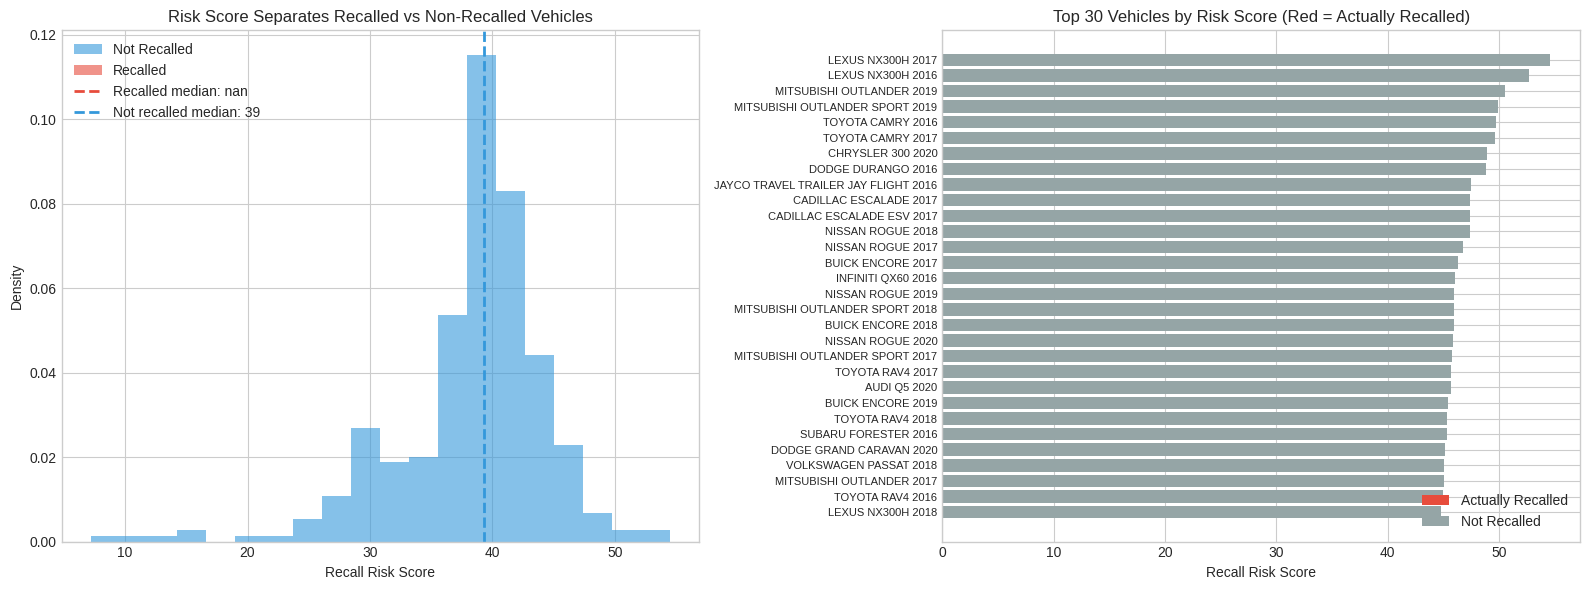

In [59]:
# 8.2 Validation charts
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

recalled     = df_vehicles[df_vehicles['actually_recalled'] == 1][SCORE_COL]
not_recalled = df_vehicles[df_vehicles['actually_recalled'] == 0][SCORE_COL]

axes[0].hist(not_recalled, bins=20, alpha=0.6, color='#3498db', label='Not Recalled', density=True)
axes[0].hist(recalled,     bins=20, alpha=0.6, color='#e74c3c', label='Recalled',     density=True)
axes[0].axvline(recalled.median(),     color='#e74c3c', linestyle='--', lw=2,
                label=f'Recalled median: {recalled.median():.0f}')
axes[0].axvline(not_recalled.median(), color='#3498db', linestyle='--', lw=2,
                label=f'Not recalled median: {not_recalled.median():.0f}')
axes[0].set_xlabel('Recall Risk Score'); axes[0].set_ylabel('Density')
axes[0].set_title('Risk Score Separates Recalled vs Non-Recalled Vehicles')
axes[0].legend()

ranked = df_vehicles_ranked.head(30)
colors = ['#e74c3c' if r == 1 else '#95a5a6' for r in ranked['actually_recalled']]
axes[1].barh(range(len(ranked)), ranked[SCORE_COL], color=colors)
axes[1].set_yticks(range(len(ranked)))
axes[1].set_yticklabels([k.replace('_',' ') for k in ranked['vehicle_key']], fontsize=8)
axes[1].invert_yaxis()
axes[1].set_xlabel('Recall Risk Score')
axes[1].set_title('Top 30 Vehicles by Risk Score (Red = Actually Recalled)')

from matplotlib.patches import Patch
axes[1].legend(handles=[
    Patch(facecolor='#e74c3c', label='Actually Recalled'),
    Patch(facecolor='#95a5a6', label='Not Recalled'),
], loc='lower right')
plt.tight_layout()
plt.savefig(drive_path('data/outputs/validation_chart.png'), dpi=150, bbox_inches='tight')
plt.show()


In [60]:
# 8.3 Case study: complaint timeline precedes recall
case_study = df_vehicles[df_vehicles['actually_recalled'] == 1].nlargest(1, SCORE_COL)

if len(case_study) > 0:
    case_vehicle = case_study.iloc[0]['vehicle_key']
    recall_date  = case_study.iloc[0].get('earliest_recall_date')

    case_complaints = df_complaints[df_complaints['vehicle_key'] == case_vehicle].copy()
    case_complaints = case_complaints.dropna(subset=['complaint_date']).sort_values('complaint_date')

    print(f'CASE STUDY: {case_vehicle}')
    print(f'Risk Score: {case_study.iloc[0][SCORE_COL]:.1f}  |  Recall Date: {recall_date}')
    print(f'Total Complaints: {len(case_complaints)}')

    monthly = case_complaints.set_index('complaint_date').resample('M')['composite_score'].agg(
        count='count', mean_score='mean'
    )
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    ax1.bar(monthly.index, monthly['count'], color='#3498db', alpha=0.7)
    ax1.set_ylabel('Monthly Complaint Count')
    ax1.set_title(f'{case_vehicle}: Complaint Volume Over Time')
    if recall_date and pd.notna(recall_date):
        ax1.axvline(pd.to_datetime(recall_date), color='red', linestyle='--', lw=2, label='Recall Date')
        ax1.legend()
    ax2.plot(monthly.index, monthly['mean_score'], color='#e74c3c', marker='o', markersize=4)
    ax2.set_ylabel('Mean Criticality Score'); ax2.set_xlabel('Date')
    ax2.set_title('Average Criticality Score Over Time')
    if recall_date and pd.notna(recall_date):
        ax2.axvline(pd.to_datetime(recall_date), color='red', linestyle='--', lw=2, label='Recall Date')
        ax2.legend()
    plt.tight_layout()
    plt.savefig(drive_path(f'data/outputs/case_study_{case_vehicle}.png'), dpi=150, bbox_inches='tight')
    plt.show()

    if recall_date and pd.notna(recall_date):
        pre_recall = case_complaints[case_complaints['complaint_date'] < pd.to_datetime(recall_date)]
        print(f'Top 5 pre-recall complaints (by criticality score):')
        for _, row in pre_recall.nlargest(5, 'composite_score').iterrows():
            print(f'  Date: {row["complaint_date"].date()}  Score: {row["composite_score"]:.1f}')
            print(f'  {str(row.get("summary",""))[:200]}')


In [61]:
# 8.4 Final results table + presentation metrics
EXPORT_COLS_WANTED = [
    'vehicle_key', SCORE_COL, 'actually_recalled',
    'n_complaints','mean_composite_score','crash_rate','injury_rate',
    'temporal_acceleration','safety_category_rate',
    'dominant_defect_category','sbert_cluster_rate',
]
export_cols   = [c for c in EXPORT_COLS_WANTED if c in df_vehicles_ranked.columns]
final_results = df_vehicles_ranked[export_cols].copy()
final_results['risk_tier'] = pd.cut(
    final_results[SCORE_COL], bins=[0,30,50,70,100],
    labels=['LOW','MEDIUM','HIGH','CRITICAL']
)
print('FINAL RESULTS TABLE:')
print(final_results.head(20).to_string(index=False))
final_results.to_csv(drive_path('data/outputs/vehicle_recall_risk_final.csv'), index=False)
print('Saved -> data/outputs/vehicle_recall_risk_final.csv')

print('\nKEY METRICS FOR PRESENTATION:')
print(f'  Unique vehicles assessed : {len(df_vehicles)}')
print(f'  Vehicles recalled        : {df_vehicles["actually_recalled"].sum()} ({df_vehicles["actually_recalled"].mean():.0%})')
print(f'  Top-20 precision         : {top_20_precision:.0%}')
if roc_auc: print(f'  ROC-AUC                  : {roc_auc:.3f}')
if pr_auc:  print(f'  PR-AUC                   : {pr_auc:.3f}')
print(f'  Lift over baseline       : {lift:.1f}x')
print('\nRisk tier distribution:')
for tier, count in final_results['risk_tier'].value_counts().sort_index(ascending=False).items():
    recalled_in = final_results[final_results['risk_tier'] == tier]['actually_recalled'].sum()
    print(f'  {tier:<10} {count:>4} vehicles  ({recalled_in} recalled)')


FINAL RESULTS TABLE:
                         vehicle_key  recall_risk_v2  actually_recalled  n_complaints  mean_composite_score  crash_rate  injury_rate  temporal_acceleration  safety_category_rate dominant_defect_category  sbert_cluster_rate risk_tier
                   LEXUS_NX300H_2017           54.54                  0            11                 51.65       0.364        0.273                  0.000                 0.909            AIRBAG_DEFECT               0.182      HIGH
                   LEXUS_NX300H_2016           52.73                  0            17                 47.33       0.294        0.176                  0.000                 1.000            AIRBAG_DEFECT               0.235      HIGH
           MITSUBISHI_OUTLANDER_2019           50.57                  0            32                 43.07       0.250        0.156                 -0.056                 0.969            AIRBAG_DEFECT               0.219      HIGH
     MITSUBISHI_OUTLANDER SPORT_2019           

---
## Section 9 - API Playground / Sandbox
> Quick API exploration cells. Do not affect any saved files.

In [62]:
# Single vehicle complaint pull -- quick test
url    = 'https://api.nhtsa.gov/complaints/complaintsByVehicle'
params = {'make': 'TOYOTA', 'model': 'CAMRY', 'modelYear': 2012}
r      = requests.get(url, params=params, timeout=15)
r.raise_for_status()
results = r.json().get('results', [])
print(f'Total complaints returned: {len(results)}')
if results:
    print('\nField listing for first record:')
    for k, v in results[0].items():
        print(f'  {k:<30}  {v}')


Total complaints returned: 644

Field listing for first record:
  odiNumber                       11757762
  manufacturer                    Toyota Motor Corporation
  crash                           False
  fire                            False
  numberOfInjuries                0
  numberOfDeaths                  0
  dateOfIncident                  07/27/2026
  dateComplaintFiled              08/18/2026
  vin                             4T1BF1FK9CU
  components                      POWER TRAIN,ENGINE
  summary                         2012 Toyota Camry LE developed severe transmission shudder/vibration during normal driving, especially around 25–35 mph and 45–60 mph. The vehicle also experienced noticeable vibration when shifting into Reverse and Drive. An OBD scan previously detected diagnostic trouble code P2716 related to transmission pressure control. The transmission fluid was serviced, but the shudder continued. While driving on the highway, the check-engine light came on again. 

In [63]:
# Makes for a given year
url    = 'https://api.nhtsa.gov/products/vehicle/makes'
params = {'modelYear': 2021, 'issueType': 'c'}
r      = requests.get(url, params=params, timeout=15)
r.raise_for_status()
print([m.get('make') for m in r.json().get('results', [])])


['4 STAR', 'ACURA', 'AIRSTREAM', 'ALFA ROMEO', 'ALINER', 'ALLIANCE RV', 'ALUMA', 'ALUMINUM TRAILER CO', 'AMERICAN COACH', 'APRILIA', 'ARCIMOTO', 'AUDI', 'AUTOCAR', 'BENTLEY', 'BIG TEX', 'BLACKSERIES CAMPERS', 'BLUE BIRD', 'BMW', 'BRAXTON CREEK', 'BUBBLE BUDDY', 'BUICK', 'CADILLAC', 'CAN-AM', 'CARRY-ON', 'CHEVROLET', 'CHRYSLER', 'COACHMEN', 'CONTINENTAL CARGO', 'CRUISER', 'DODGE', 'DRV', 'DUCATI', 'DUTCHMEN', 'DYNAMAX', 'EARTHROAMER', 'EAST TO WEST', 'ELECTRAMECCANICA', 'ENTEGRA', 'EZ LOADER', 'FCCC', 'FERRARI', 'FLEETWOOD', 'FORD', 'FOREST RIVER', 'FREIGHTLINER', 'GENESIS', 'GENESIS SUPREME', 'GENUINE SCOOTER', 'GMC', 'GRAND DESIGN', 'GRECH', 'GREENPOWER', 'GULF STREAM', 'HARLEY-DAVIDSON', 'HEARTLAND', 'HIGHLAND RIDGE', 'HOLIDAY HOUSE', 'HOLIDAY RAMBLER', 'HOLMES ENTERPRISES', 'HOMESTEADER', 'HONDA', 'HUSQVARNA', 'HYUNDAI', 'IC BUS', 'ICON EV', 'INDIAN', 'INFINITI', 'INTECH', 'INTERNATIONAL', 'INTERSTATE', 'JAGUAR', 'JAYCO', 'JAYCO TRAVEL TRAILER', 'JEEP', 'KARAVAN', 'KAWASAKI', 'KENDO

In [64]:
# Models for a specific make + year
url    = 'https://api.nhtsa.gov/products/vehicle/models'
params = {'modelYear': 2020, 'issueType': 'c', 'make': 'VOLKSWAGEN'}
r      = requests.get(url, params=params, timeout=15)
r.raise_for_status()
print([m.get('model') for m in r.json().get('results', [])])


['PASSAT', 'ARTEON', 'ATLAS CROSS SPORT', 'GOLF', 'GOLF GTI', 'JETTA', 'TIGUAN', 'ARTEON', 'ATLAS CROSS SPORT', 'TIGUAN', 'ATLAS', 'ATLAS']
